<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/Santander60cutoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/content"))

if os.path.exists("/content/drive"):
    print("Inside /content/drive:", os.listdir("/content/drive"))

['.config', 'drive', 'sample_data']
Inside /content/drive: ['MyDrive']


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive")[:20])

['Santander_External_Validation_Results']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Santander_External_Validation_Results"):
    for f in files:
        print(os.path.join(root, f))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kiểm tra thông tin dữ liệu file Santander Product Recommendation

In [ ]:

# ==============================================
# STEP 1. Mount Google Drive
# ==============================================

from google.colab import drive
drive.mount('/content/drive')

# ==============================================
# STEP 2. Tìm file train_ver2.csv
# ==============================================

import os

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "train_ver2.csv" in files:
        file_path = os.path.join(root, "train_ver2.csv")
        break

if file_path is None:
    raise FileNotFoundError("Không tìm thấy train_ver2.csv trong Google Drive!")

print("Đã tìm thấy file:")
print(file_path)

# ==============================================
# STEP 3. Chỉ giữ các cột cần thiết
# ==============================================

keep_columns = [
    "fecha_dato",
    "ncodpers",
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "fecha_alta",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "ult_fec_cli_1t",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
    "ind_tjcr_fin_ult1"
]

# ==============================================
# STEP 4. Đọc theo từng chunk
# ==============================================

import pandas as pd

output_file = "/content/drive/MyDrive/Santander_CreditCard.csv"

chunksize = 500000

first_chunk = True
total_rows = 0

for chunk in pd.read_csv(
    file_path,
    usecols=keep_columns,
    chunksize=chunksize,
    low_memory=False
):

    total_rows += len(chunk)

    chunk.to_csv(
        output_file,
        mode='w' if first_chunk else 'a',
        header=first_chunk,
        index=False
    )

    print(f"Đã xử lý {total_rows:,} dòng")

    first_chunk = False

print("="*60)
print("HOÀN THÀNH!")
print("File đã lưu tại:")
print(output_file)

# ==============================================
# STEP 5. Kiểm tra file mới
# ==============================================

df = pd.read_csv(output_file, nrows=5)

print(df.head())

print(df.columns.tolist())

print("Số cột:", len(df.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã tìm thấy file:
/content/drive/MyDrive/train_ver2.csv
Đã xử lý 500,000 dòng
Đã xử lý 1,000,000 dòng
Đã xử lý 1,500,000 dòng
Đã xử lý 2,000,000 dòng
Đã xử lý 2,500,000 dòng
Đã xử lý 3,000,000 dòng
Đã xử lý 3,500,000 dòng
Đã xử lý 4,000,000 dòng
Đã xử lý 4,500,000 dòng
Đã xử lý 5,000,000 dòng
Đã xử lý 5,500,000 dòng
Đã xử lý 6,000,000 dòng
Đã xử lý 6,500,000 dòng
Đã xử lý 7,000,000 dòng
Đã xử lý 7,500,000 dòng
Đã xử lý 8,000,000 dòng
Đã xử lý 8,500,000 dòng
Đã xử lý 9,000,000 dòng
Đã xử lý 9,500,000 dòng
Đã xử lý 10,000,000 dòng
Đã xử lý 10,500,000 dòng
Đã xử lý 11,000,000 dòng
Đã xử lý 11,500,000 dòng
Đã xử lý 12,000,000 dòng
Đã xử lý 12,500,000 dòng
Đã xử lý 13,000,000 dòng
Đã xử lý 13,500,000 dòng
Đã xử lý 13,647,309 dòng
HOÀN THÀNH!
File đã lưu tại:
/content/drive/MyDrive/Santander_CreditCard.csv
   fecha_dato  ncodpers ind_empleado pais_residencia sexo  

XỬ LÝ LAKELAGE VÀ GỘP DỮ LIỆU

In [ ]:
# ==========================================================
# SANTANDER FIXED 60-DAY CUTOFF - LOW RAM
#
# Feature window:
#   fecha_alta <= fecha_dato <= fecha_alta + 60 ngày
#
# Exclusion:
#   Loại khách hàng đã có thẻ trong hoặc trước cutoff 60 ngày
#
# Target:
#   TARGET_60D = 1 nếu có thẻ sau cutoff 60 ngày
#   trong bất kỳ thời điểm nào còn lại của dữ liệu
#
# Không giới hạn trong năm đầu tiên
# ==========================================================


# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")


# ==========================================================
# 2. Cài đặt và import thư viện
# ==========================================================

!pip -q install duckdb

import os
import gc
import shutil
import duckdb
import pandas as pd


# ==========================================================
# 3. Tự động tìm file Santander_CreditCard.csv
# ==========================================================

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard.csv" in files:
        input_file = os.path.join(
            root,
            "Santander_CreditCard.csv"
        )
        break

if input_file is None:
    raise FileNotFoundError(
        "Không tìm thấy file Santander_CreditCard.csv "
        "trong Google Drive."
    )

print("=" * 80)
print("Đang sử dụng file:")
print(input_file)
print("=" * 80)


# ==========================================================
# 4. Đường dẫn kết quả và dữ liệu tạm
# ==========================================================

temp_dir = "/content/santander_duckdb_temp"

database_file = "/content/santander_60d.duckdb"

output_audit_file = (
    "/content/drive/MyDrive/"
    "Santander_CreditCard_Fixed60D_Audit.csv"
)

output_model_file = (
    "/content/drive/MyDrive/"
    "Santander_CreditCard_Fixed60D_Model.csv"
)


# Xóa dữ liệu tạm từ lần chạy trước
if os.path.exists(temp_dir):
    shutil.rmtree(
        temp_dir,
        ignore_errors=True
    )

os.makedirs(
    temp_dir,
    exist_ok=True
)

if os.path.exists(database_file):
    os.remove(database_file)


# ==========================================================
# 5. Khởi tạo DuckDB với giới hạn RAM
# ==========================================================

con = duckdb.connect(database_file)

# Có thể giảm xuống 3GB nếu Colab vẫn thiếu RAM
con.execute("SET memory_limit = '4GB'")
con.execute("SET threads = 2")
con.execute(f"SET temp_directory = '{temp_dir}'")
con.execute("SET preserve_insertion_order = false")

print("DuckDB memory limit: 4GB")
print("Số luồng xử lý: 2")


# ==========================================================
# 6. Danh sách feature
# ==========================================================

last_cols = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento"
]

first_cols = [
    "canal_entrada"
]

all_feature_cols = (
    last_cols
    + first_cols
)


# ==========================================================
# 7. Kiểm tra các cột trong file
# ==========================================================

print("\nĐang kiểm tra cấu trúc file...")

column_info = con.execute(
    f"""
    DESCRIBE
    SELECT *
    FROM read_csv(
        '{input_file}',
        header = true,
        all_varchar = true,
        sample_size = 10000,
        ignore_errors = true
    )
    LIMIT 1
    """
).fetchdf()

available_cols = (
    column_info["column_name"]
    .tolist()
)

required_cols = [
    "ncodpers",
    "fecha_dato",
    "fecha_alta",
    "ind_tjcr_fin_ult1"
]

missing_required = [
    col
    for col in required_cols
    if col not in available_cols
]

if missing_required:
    raise ValueError(
        f"File thiếu các cột bắt buộc: "
        f"{missing_required}"
    )

missing_features = [
    col
    for col in all_feature_cols
    if col not in available_cols
]

if missing_features:
    print(
        "\nCác feature sau không có trong file "
        "và sẽ được gán NULL:"
    )
    print(missing_features)


# ==========================================================
# 8. Tạo câu lệnh đọc feature
# ==========================================================

raw_feature_select = []

for col in all_feature_cols:

    if col in available_cols:
        raw_feature_select.append(
            f"""
            NULLIF(
                TRIM("{col}"),
                ''
            ) AS "{col}"
            """
        )

    else:
        raw_feature_select.append(
            f"""
            NULL::VARCHAR AS "{col}"
            """
        )

raw_feature_sql = ",\n".join(
    raw_feature_select
)


# ==========================================================
# 9. Tạo bảng raw_data
#
# Không nạp toàn bộ CSV vào Pandas.
# DuckDB đọc và ghi trực tiếp xuống ổ đĩa.
# ==========================================================

print("\n" + "=" * 80)
print("BƯỚC 1: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU")
print("=" * 80)

con.execute("DROP TABLE IF EXISTS raw_data")

con.execute(
    f"""
    CREATE TABLE raw_data AS

    SELECT
        TRY_CAST(
            NULLIF(
                TRIM(ncodpers),
                ''
            )
            AS BIGINT
        ) AS ncodpers,

        TRY_CAST(
            NULLIF(
                TRIM(fecha_dato),
                ''
            )
            AS DATE
        ) AS fecha_dato,

        TRY_CAST(
            NULLIF(
                TRIM(fecha_alta),
                ''
            )
            AS DATE
        ) AS fecha_alta,

        CASE
            WHEN TRY_CAST(
                NULLIF(
                    TRIM(ind_tjcr_fin_ult1),
                    ''
                )
                AS DOUBLE
            ) > 0
            THEN 1
            ELSE 0
        END AS has_card,

        {raw_feature_sql}

    FROM read_csv(
        '{input_file}',
        header = true,
        all_varchar = true,
        sample_size = 10000,
        ignore_errors = true
    )

    WHERE
        TRY_CAST(
            NULLIF(
                TRIM(ncodpers),
                ''
            )
            AS BIGINT
        ) IS NOT NULL

        AND TRY_CAST(
            NULLIF(
                TRIM(fecha_dato),
                ''
            )
            AS DATE
        ) IS NOT NULL

        AND TRY_CAST(
            NULLIF(
                TRIM(fecha_alta),
                ''
            )
            AS DATE
        ) IS NOT NULL
    """
)

raw_stats = con.execute(
    """
    SELECT
        COUNT(*) AS number_of_rows,
        COUNT(DISTINCT ncodpers)
            AS number_of_customers,
        MIN(fecha_dato)
            AS min_snapshot_date,
        MAX(fecha_dato)
            AS max_snapshot_date
    FROM raw_data
    """
).fetchdf()

print("\nDữ liệu sau chuẩn hóa:")
print(raw_stats.to_string(index=False))


# ==========================================================
# 10. Chuẩn hóa fecha_alta theo khách hàng
#
# Nếu fecha_alta bị thay đổi hoặc không nhất quán,
# lấy fecha_alta sớm nhất của từng khách hàng.
# ==========================================================

print("\nĐang chuẩn hóa fecha_alta...")

con.execute(
    """
    CREATE OR REPLACE TABLE clean_data AS

    SELECT
        ncodpers,
        fecha_dato,

        MIN(fecha_alta) OVER (
            PARTITION BY ncodpers
        ) AS fecha_alta,

        has_card,

        * EXCLUDE (
            ncodpers,
            fecha_dato,
            fecha_alta,
            has_card
        )

    FROM raw_data
    """
)

# Giải phóng bảng thô
con.execute("DROP TABLE raw_data")


# ==========================================================
# 11. Tạo biểu thức lấy feature cuối trong 60 ngày
# ==========================================================

last_aggregation = []

for col in last_cols:
    last_aggregation.append(
        f"""
        ARG_MAX(
            "{col}",
            fecha_dato
        ) FILTER (
            WHERE "{col}" IS NOT NULL
        ) AS "{col}"
        """
    )

first_aggregation = []

for col in first_cols:
    first_aggregation.append(
        f"""
        ARG_MIN(
            "{col}",
            fecha_dato
        ) FILTER (
            WHERE "{col}" IS NOT NULL
        ) AS "{col}"
        """
    )

feature_aggregation_sql = ",\n".join(
    last_aggregation
    + first_aggregation
)


# ==========================================================
# 12. Tạo feature window 60 ngày
#
# Chỉ lấy:
# fecha_alta <= fecha_dato <= fecha_alta + 60 ngày
# ==========================================================

print("\n" + "=" * 80)
print("BƯỚC 2: TẠO FEATURE WINDOW 60 NGÀY")
print("=" * 80)

con.execute(
    f"""
    CREATE OR REPLACE TABLE feature_window AS

    SELECT
        ncodpers,
        fecha_alta,

        CAST(
            fecha_alta + INTERVAL '60 days'
            AS DATE
        ) AS cutoff_date,

        MAX(fecha_dato)
            AS last_feature_snapshot,

        DATE_DIFF(
            'day',
            fecha_alta,
            MAX(fecha_dato)
        ) AS observed_feature_days,

        COUNT(*)
            AS n_feature_snapshots,

        MAX(has_card)
            AS adopted_within_60d,

        {feature_aggregation_sql}

    FROM clean_data

    WHERE
        fecha_dato >= fecha_alta
        AND fecha_dato <=
            fecha_alta + INTERVAL '60 days'

    GROUP BY
        ncodpers,
        fecha_alta
    """
)

feature_stats = con.execute(
    """
    SELECT
        COUNT(*) AS customers_with_feature_data,

        SUM(
            CASE
                WHEN adopted_within_60d = 1
                THEN 1
                ELSE 0
            END
        ) AS customers_adopting_within_60d,

        SUM(
            CASE
                WHEN adopted_within_60d = 0
                THEN 1
                ELSE 0
            END
        ) AS customers_retained

    FROM feature_window
    """
).fetchdf()

print(feature_stats.to_string(index=False))


# ==========================================================
# 13. Tạo target sau cutoff 60 ngày
#
# Không giới hạn trong năm đầu tiên.
# Quét toàn bộ phần dữ liệu sau cutoff.
# ==========================================================

print("\n" + "=" * 80)
print("BƯỚC 3: TẠO TARGET STRICTLY AFTER 60 DAYS")
print("=" * 80)

con.execute(
    """
    CREATE OR REPLACE TABLE target_after_60d AS

    SELECT
        ncodpers,

        MAX(
            CASE
                WHEN has_card = 1
                THEN 1
                ELSE 0
            END
        )::INTEGER AS TARGET_60D,

        MIN(fecha_dato) FILTER (
            WHERE has_card = 1
        ) AS first_card_date_after_cutoff,

        MAX(fecha_dato)
            AS last_available_snapshot

    FROM clean_data

    WHERE
        fecha_dato >
            fecha_alta + INTERVAL '60 days'

    GROUP BY ncodpers
    """
)


# ==========================================================
# 14. Tạo dữ liệu customer-level cuối cùng
#
# Loại hoàn toàn khách hàng mở thẻ trong 60 ngày đầu.
# ==========================================================

con.execute(
    f"""
    CREATE OR REPLACE TABLE customer_level AS

    SELECT
        f.ncodpers,
        f.fecha_alta,
        f.cutoff_date,
        f.last_feature_snapshot,

        t.first_card_date_after_cutoff,
        t.last_available_snapshot,

        f.observed_feature_days,
        f.n_feature_snapshots,

        {", ".join(
            [f'f."{col}"'
             for col in all_feature_cols]
        )},

        COALESCE(
            t.TARGET_60D,
            0
        )::INTEGER AS TARGET_60D

    FROM feature_window AS f

    LEFT JOIN target_after_60d AS t
        ON f.ncodpers = t.ncodpers

    WHERE
        f.adopted_within_60d = 0
    """
)


# ==========================================================
# 15. Giải phóng các bảng trung gian lớn
# ==========================================================

con.execute("DROP TABLE clean_data")
con.execute("DROP TABLE feature_window")
con.execute("DROP TABLE target_after_60d")

con.execute("CHECKPOINT")

gc.collect()


# ==========================================================
# 16. Kiểm tra kết quả
# ==========================================================

print("\n" + "=" * 80)
print("KẾT QUẢ FIXED 60-DAY CUTOFF")
print("=" * 80)

summary = con.execute(
    """
    SELECT
        COUNT(*)
            AS number_of_rows,

        COUNT(DISTINCT ncodpers)
            AS unique_customers,

        SUM(
            CASE
                WHEN TARGET_60D = 1
                THEN 1
                ELSE 0
            END
        ) AS positives,

        SUM(
            CASE
                WHEN TARGET_60D = 0
                THEN 1
                ELSE 0
            END
        ) AS negatives,

        AVG(
            TARGET_60D::DOUBLE
        ) AS positive_rate

    FROM customer_level
    """
).fetchdf()

print(summary.to_string(index=False))


print("\nPhân bố TARGET_60D:")

target_distribution = con.execute(
    """
    SELECT
        TARGET_60D,

        COUNT(*)
            AS frequency,

        COUNT(*) * 1.0
        / SUM(COUNT(*)) OVER ()
            AS proportion

    FROM customer_level

    GROUP BY TARGET_60D
    ORDER BY TARGET_60D
    """
).fetchdf()

print(
    target_distribution
    .to_string(index=False)
)


# ==========================================================
# 17. Leakage audit
# ==========================================================

print("\n" + "=" * 80)
print("LEAKAGE AUDIT")
print("=" * 80)

leakage_audit = con.execute(
    """
    SELECT
        SUM(
            CASE
                WHEN last_feature_snapshot >
                     cutoff_date
                THEN 1
                ELSE 0
            END
        ) AS feature_snapshots_after_cutoff,

        SUM(
            CASE
                WHEN TARGET_60D = 1
                 AND first_card_date_after_cutoff
                     <= cutoff_date
                THEN 1
                ELSE 0
            END
        ) AS positive_events_at_or_before_cutoff,

        SUM(
            CASE
                WHEN TARGET_60D = 1
                 AND first_card_date_after_cutoff
                     IS NULL
                THEN 1
                ELSE 0
            END
        ) AS positive_without_event_date,

        SUM(
            CASE
                WHEN TARGET_60D = 0
                 AND first_card_date_after_cutoff
                     IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) AS negative_with_event_date

    FROM customer_level
    """
).fetchdf()

print(
    leakage_audit
    .to_string(index=False)
)


# ==========================================================
# 18. Thời gian từ cutoff đến mở thẻ
# ==========================================================

event_delay = con.execute(
    """
    SELECT
        COUNT(*)
            AS positive_customers,

        MIN(
            DATE_DIFF(
                'day',
                cutoff_date,
                first_card_date_after_cutoff
            )
        ) AS min_days_after_cutoff,

        AVG(
            DATE_DIFF(
                'day',
                cutoff_date,
                first_card_date_after_cutoff
            )
        ) AS mean_days_after_cutoff,

        MEDIAN(
            DATE_DIFF(
                'day',
                cutoff_date,
                first_card_date_after_cutoff
            )
        ) AS median_days_after_cutoff,

        MAX(
            DATE_DIFF(
                'day',
                cutoff_date,
                first_card_date_after_cutoff
            )
        ) AS max_days_after_cutoff

    FROM customer_level

    WHERE TARGET_60D = 1
    """
).fetchdf()

print("\nThời gian từ cutoff đến mở thẻ:")
print(event_delay.to_string(index=False))


# ==========================================================
# 19. Kiểm tra độ phủ cửa sổ feature
# ==========================================================

print("\n" + "=" * 80)
print("FEATURE-WINDOW COVERAGE")
print("=" * 80)

coverage = con.execute(
    """
    SELECT
        MIN(observed_feature_days)
            AS min_observed_days,

        AVG(observed_feature_days)
            AS mean_observed_days,

        MEDIAN(observed_feature_days)
            AS median_observed_days,

        MAX(observed_feature_days)
            AS max_observed_days,

        AVG(
            CASE
                WHEN observed_feature_days >= 45
                THEN 1.0
                ELSE 0.0
            END
        ) AS coverage_at_least_45d,

        AVG(
            CASE
                WHEN observed_feature_days >= 60
                THEN 1.0
                ELSE 0.0
            END
        ) AS coverage_at_least_60d,

        AVG(n_feature_snapshots)
            AS mean_feature_snapshots

    FROM customer_level
    """
).fetchdf()

print(coverage.to_string(index=False))


# ==========================================================
# 20. Kiểm tra ID trùng
# ==========================================================

duplicate_check = con.execute(
    """
    SELECT
        COUNT(*)
            AS duplicated_customer_ids

    FROM (
        SELECT
            ncodpers,
            COUNT(*) AS number_of_rows

        FROM customer_level

        GROUP BY ncodpers
        HAVING COUNT(*) > 1
    )
    """
).fetchdf()

print("\nKiểm tra ID trùng:")
print(duplicate_check.to_string(index=False))


# ==========================================================
# 21. Lưu file audit
# ==========================================================

print("\n" + "=" * 80)
print("ĐANG LƯU FILE")
print("=" * 80)

con.execute(
    f"""
    COPY customer_level
    TO '{output_audit_file}'
    (
        HEADER,
        DELIMITER ','
    )
    """
)

print("\nĐã lưu file audit:")
print(output_audit_file)


# ==========================================================
# 22. Lưu file model
#
# File model không chứa:
# - ID
# - Các biến ngày
# - observed_feature_days
# - n_feature_snapshots
# ==========================================================

model_feature_sql = ",\n".join(
    [
        f'"{col}"'
        for col in all_feature_cols
    ]
)

con.execute(
    f"""
    COPY (
        SELECT
            {model_feature_sql},
            TARGET_60D

        FROM customer_level
    )
    TO '{output_model_file}'
    (
        HEADER,
        DELIMITER ','
    )
    """
)

print("\nĐã lưu file model:")
print(output_model_file)


# ==========================================================
# 23. Xem trước 10 dòng
# ==========================================================

preview = con.execute(
    """
    SELECT *
    FROM customer_level
    LIMIT 10
    """
).fetchdf()

print("\n10 dòng đầu:")
display(preview)


# ==========================================================
# 24. Đóng kết nối và giải phóng RAM
# ==========================================================

con.close()

gc.collect()

if os.path.exists(temp_dir):
    shutil.rmtree(
        temp_dir,
        ignore_errors=True
    )

print("\n" + "=" * 80)
print("HOÀN THÀNH")
print("=" * 80)

print("Feature chỉ được lấy trong 60 ngày đầu.")
print("Khách hàng mở thẻ trong 60 ngày đầu đã bị loại.")
print("Target được xác định từ toàn bộ dữ liệu sau ngày 60.")

Mounted at /content/drive
Đang sử dụng file:
/content/drive/MyDrive/Santander_CreditCard.csv
DuckDB memory limit: 4GB
Số luồng xử lý: 2

Đang kiểm tra cấu trúc file...

BƯỚC 1: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Dữ liệu sau chuẩn hóa:
 number_of_rows  number_of_customers min_snapshot_date max_snapshot_date
       13619575               949614        2015-01-28        2016-05-28

Đang chuẩn hóa fecha_alta...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


BƯỚC 2: TẠO FEATURE WINDOW 60 NGÀY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 customers_with_feature_data  customers_adopting_within_60d  customers_retained
                      153677                          278.0            153399.0

BƯỚC 3: TẠO TARGET STRICTLY AFTER 60 DAYS

KẾT QUẢ FIXED 60-DAY CUTOFF
 number_of_rows  unique_customers  positives  negatives  positive_rate
         153399            153399      992.0   152407.0       0.006467

Phân bố TARGET_60D:
 TARGET_60D  frequency  proportion
          0     152407    0.993533
          1        992    0.006467

LEAKAGE AUDIT
 feature_snapshots_after_cutoff  positive_events_at_or_before_cutoff  positive_without_event_date  negative_with_event_date
                            0.0                                  0.0                          0.0                       0.0

Thời gian từ cutoff đến mở thẻ:
 positive_customers  min_days_after_cutoff  mean_days_after_cutoff  median_days_after_cutoff  max_days_after_cutoff
                992                      1              118.073589                      

,ncodpers,fecha_alta,cutoff_date,last_feature_snapshot,first_card_date_after_cutoff,last_available_snapshot,observed_feature_days,n_feature_snapshots,ind_empleado,pais_residencia,...,conyuemp,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,canal_entrada,TARGET_60D
0,1493085,2015-10-28,2015-12-27,2015-11-28,NaT,2016-05-28,31,2,N,ES,...,None,N,1,46.0,VALENCIA,1,None,03 - UNIVERSITARIO,KHQ,0
1,1493392,2015-10-28,2015-12-27,2015-11-28,NaT,2016-05-28,31,2,N,ES,...,None,N,1,48.0,BIZKAIA,1,None,01 - TOP,KHN,0
2,1494110,2015-10-29,2015-12-28,2015-12-28,NaT,2016-05-28,60,2,N,ES,...,None,N,1,41.0,SEVILLA,1,None,03 - UNIVERSITARIO,KHQ,0
3,1494583,2015-10-29,2015-12-28,2015-12-28,NaT,2016-05-28,60,2,N,ES,...,None,N,1,50.0,ZARAGOZA,1,None,02 - PARTICULARES,KHM,0
4,1495061,2015-10-30,2015-12-29,2015-12-28,NaT,2016-05-28,59,2,N,ES,...,None,N,1,28.0,MADRID,0,None,03 - UNIVERSITARIO,KHQ,0
5,1495550,2015-10-30,2015-12-29,2015-12-28,NaT,2016-05-28,59,2,N,ES,...,None,N,1,30.0,MURCIA,1,None,02 - PARTICULARES,KHM,0
6,1495973,2015-11-02,2016-01-01,2015-12-28,NaT,2016-05-28,56,2,N,ES,...,None,N,1,28.0,MADRID,0,None,03 - UNIVERSITARIO,KHQ,0
7,1496087,2015-11-02,2016-01-01,2015-12-28,NaT,2016-05-28,56,2,N,ES,...,None,N,1,14.0,CORDOBA,0,None,03 - UNIVERSITARIO,KHQ,0
8,1496105,2015-11-02,2016-01-01,2015-12-28,NaT,2016-05-28,56,2,N,ES,...,None,N,1,28.0,MADRID,0,None,03 - UNIVERSITARIO,KHQ,0
9,1496491,2015-11-02,2016-01-01,2015-12-28,NaT,2016-05-28,56,2,N,ES,...,None,N,1,8.0,BARCELONA,0,None,02 - PARTICULARES,KHM,0



HOÀN THÀNH
Feature chỉ được lấy trong 60 ngày đầu.
Khách hàng mở thẻ trong 60 ngày đầu đã bị loại.
Target được xác định từ toàn bộ dữ liệu sau ngày 60.


In [ ]:
# ==========================================================
# SANTANDER FIXED 60-DAY CUTOFF
#
# Feature window:
#   fecha_alta <= fecha_dato <= fecha_alta + 60 ngày
#
# Exclusion:
#   Loại khách hàng mở thẻ trong 60 ngày đầu
#
# Target:
#   TARGET_60D = max(ind_tjcr_fin_ult1)
#   trên toàn bộ dữ liệu sau ngày thứ 60
# ==========================================================


# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")


# ==========================================================
# 2. Import thư viện
# ==========================================================

import os
import gc
import pandas as pd
import numpy as np


# ==========================================================
# 3. Tự động tìm file Santander_CreditCard.csv
# ==========================================================

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard.csv" in files:
        input_file = os.path.join(
            root,
            "Santander_CreditCard.csv"
        )
        break

if input_file is None:
    raise FileNotFoundError(
        "Không tìm thấy file Santander_CreditCard.csv "
        "trong Google Drive."
    )

print("=" * 80)
print("Đang đọc file:")
print(input_file)
print("=" * 80)


# ==========================================================
# 4. Chỉ đọc các cột cần thiết để giảm RAM
# ==========================================================

required_cols = [
    "ncodpers",
    "fecha_dato",
    "fecha_alta",
    "ind_tjcr_fin_ult1"
]

last_cols = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento"
]

first_cols = [
    "canal_entrada"
]

usecols = (
    required_cols
    + last_cols
    + first_cols
)

# Kiểm tra tên cột trước
header_cols = pd.read_csv(
    input_file,
    nrows=0
).columns.tolist()

missing_required = [
    col for col in required_cols
    if col not in header_cols
]

if missing_required:
    raise ValueError(
        f"File thiếu các cột bắt buộc: {missing_required}"
    )

# Chỉ giữ các feature thật sự tồn tại
existing_last_cols = [
    col for col in last_cols
    if col in header_cols
]

existing_first_cols = [
    col for col in first_cols
    if col in header_cols
]

existing_usecols = (
    required_cols
    + existing_last_cols
    + existing_first_cols
)

print("\nSố cột sẽ đọc:", len(existing_usecols))

missing_features = [
    col for col in last_cols + first_cols
    if col not in header_cols
]

if missing_features:
    print("Các feature không tồn tại trong file:")
    print(missing_features)


# ==========================================================
# 5. Đọc dữ liệu
# ==========================================================

df = pd.read_csv(
    input_file,
    usecols=existing_usecols,
    low_memory=True
)

print("\nKích thước dữ liệu gốc:", df.shape)


# ==========================================================
# 6. Chuẩn hóa kiểu dữ liệu
# ==========================================================

df["fecha_dato"] = pd.to_datetime(
    df["fecha_dato"],
    errors="coerce"
)

df["fecha_alta"] = pd.to_datetime(
    df["fecha_alta"],
    errors="coerce"
)

df["ncodpers"] = pd.to_numeric(
    df["ncodpers"],
    errors="coerce"
)

df["ind_tjcr_fin_ult1"] = pd.to_numeric(
    df["ind_tjcr_fin_ult1"],
    errors="coerce"
).fillna(0)

df["ind_tjcr_fin_ult1"] = (
    df["ind_tjcr_fin_ult1"] > 0
).astype("int8")


# Loại dòng thiếu ID hoặc ngày quan trọng
df = df.dropna(
    subset=[
        "ncodpers",
        "fecha_dato",
        "fecha_alta"
    ]
).copy()

df["ncodpers"] = df["ncodpers"].astype("int64")


# ==========================================================
# 7. Chuẩn hóa fecha_alta theo từng khách hàng
#
# Nếu fecha_alta không nhất quán giữa các snapshot,
# lấy fecha_alta sớm nhất của khách hàng.
# ==========================================================

customer_start = (
    df.groupby("ncodpers")["fecha_alta"]
      .transform("min")
)

df["fecha_alta"] = customer_start

del customer_start
gc.collect()


# ==========================================================
# 8. Xác định cutoff 60 ngày
# ==========================================================

df["cutoff_date"] = (
    df["fecha_alta"]
    + pd.Timedelta(days=60)
)

# Chỉ giữ snapshot từ ngày bắt đầu quan hệ trở đi
df = df[
    df["fecha_dato"] >= df["fecha_alta"]
].copy()

print(
    "Kích thước sau khi loại snapshot trước fecha_alta:",
    df.shape
)


# ==========================================================
# 9. Chia dữ liệu thành:
#
# - feature_window: từ fecha_alta đến hết ngày 60
# - target_window: strictly after ngày 60
# ==========================================================

feature_mask = (
    df["fecha_dato"]
    <= df["cutoff_date"]
)

target_mask = (
    df["fecha_dato"]
    > df["cutoff_date"]
)

feature_window = df.loc[
    feature_mask
].copy()

target_window = df.loc[
    target_mask,
    [
        "ncodpers",
        "fecha_dato",
        "ind_tjcr_fin_ult1"
    ]
].copy()

print("\nSố dòng trong feature window 60 ngày:")
print(len(feature_window))

print("\nSố dòng sau cutoff 60 ngày:")
print(len(target_window))


# Không cần giữ DataFrame gốc nữa
del df
del feature_mask
del target_mask

gc.collect()


# ==========================================================
# 10. Xác định khách hàng mở thẻ trong 60 ngày đầu
# ==========================================================

early_adopter = (
    feature_window
    .groupby("ncodpers")["ind_tjcr_fin_ult1"]
    .max()
    .rename("adopted_within_60d")
    .reset_index()
)

print("\nSố khách hàng có dữ liệu trong 60 ngày đầu:")
print(len(early_adopter))

print("\nPhân bố mở thẻ trong 60 ngày đầu:")
print(
    early_adopter["adopted_within_60d"]
    .value_counts()
    .sort_index()
)

retained_ids = early_adopter.loc[
    early_adopter["adopted_within_60d"] == 0,
    "ncodpers"
]

print("\nSố khách hàng bị loại do mở thẻ trong 60 ngày:")
print(
    int(
        (
            early_adopter["adopted_within_60d"] == 1
        ).sum()
    )
)

print("\nSố khách hàng được giữ lại:")
print(len(retained_ids))


# ==========================================================
# 11. Loại early adopter khỏi feature window
# ==========================================================

feature_window = feature_window[
    feature_window["ncodpers"].isin(retained_ids)
].copy()


# Sắp xếp để:
# - groupby.last lấy snapshot gần cutoff nhất
# - groupby.first lấy snapshot đầu tiên
feature_window = feature_window.sort_values(
    [
        "ncodpers",
        "fecha_dato"
    ]
)


# ==========================================================
# 12. Tạo các biến audit customer-level
# ==========================================================

audit_data = (
    feature_window
    .groupby("ncodpers")
    .agg(
        fecha_alta=(
            "fecha_alta",
            "first"
        ),
        cutoff_date=(
            "cutoff_date",
            "first"
        ),
        last_snapshot_date=(
            "fecha_dato",
            "max"
        ),
        n_feature_snapshots=(
            "fecha_dato",
            "size"
        )
    )
    .reset_index()
)

audit_data["observed_feature_days"] = (
    audit_data["last_snapshot_date"]
    - audit_data["fecha_alta"]
).dt.days


# ==========================================================
# 13. Lấy giá trị cuối gần cutoff nhất
# ==========================================================

if existing_last_cols:

    last_feature_data = (
        feature_window[
            ["ncodpers"] + existing_last_cols
        ]
        .groupby("ncodpers")
        .last()
        .reset_index()
    )

else:

    last_feature_data = (
        feature_window[["ncodpers"]]
        .drop_duplicates()
        .copy()
    )


# ==========================================================
# 14. Lấy giá trị đầu tiên
# ==========================================================

if existing_first_cols:

    first_feature_data = (
        feature_window[
            ["ncodpers"] + existing_first_cols
        ]
        .groupby("ncodpers")
        .first()
        .reset_index()
    )

else:

    first_feature_data = (
        feature_window[["ncodpers"]]
        .drop_duplicates()
        .copy()
    )


# ==========================================================
# 15. Tạo TARGET_60D
#
# Target = max(ind_tjcr_fin_ult1)
# trên toàn bộ snapshot strictly after ngày 60.
# ==========================================================

# Chỉ giữ khách hàng không mở thẻ trong 60 ngày đầu
target_window = target_window[
    target_window["ncodpers"].isin(retained_ids)
].copy()

target_data = (
    target_window
    .groupby("ncodpers")
    .agg(
        TARGET_60D=(
            "ind_tjcr_fin_ult1",
            "max"
        )
    )
    .reset_index()
)

# Lấy ngày đầu tiên ghi nhận có thẻ sau cutoff
positive_event_dates = (
    target_window[
        target_window["ind_tjcr_fin_ult1"] == 1
    ]
    .groupby("ncodpers")["fecha_dato"]
    .min()
    .rename("first_card_date_after_cutoff")
    .reset_index()
)

target_data = target_data.merge(
    positive_event_dates,
    on="ncodpers",
    how="left"
)


# ==========================================================
# 16. Ghép dữ liệu customer-level
# ==========================================================

customer_level = (
    audit_data
    .merge(
        last_feature_data,
        on="ncodpers",
        how="left"
    )
    .merge(
        first_feature_data,
        on="ncodpers",
        how="left"
    )
    .merge(
        target_data,
        on="ncodpers",
        how="left"
    )
)


# Khách hàng không có snapshot sau cutoff:
# hiện không ghi nhận mở thẻ, TARGET = 0
customer_level["TARGET_60D"] = (
    customer_level["TARGET_60D"]
    .fillna(0)
    .astype("int8")
)


# ==========================================================
# 17. Giải phóng dữ liệu trung gian
# ==========================================================

del feature_window
del target_window
del early_adopter
del retained_ids
del audit_data
del last_feature_data
del first_feature_data
del target_data
del positive_event_dates

gc.collect()


# ==========================================================
# 18. Kiểm tra kết quả
# ==========================================================

print("\n" + "=" * 80)
print("KẾT QUẢ FIXED 60-DAY CUTOFF")
print("=" * 80)

print(
    "Kích thước dữ liệu cuối:",
    customer_level.shape
)

print("\nPhân bố TARGET_60D:")
print(
    customer_level["TARGET_60D"]
    .value_counts()
    .sort_index()
)

print("\nTỷ lệ TARGET_60D:")
print(
    customer_level["TARGET_60D"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nKiểm tra số khách hàng:")
print(
    "Số dòng:",
    len(customer_level)
)

print(
    "Số khách hàng duy nhất:",
    customer_level["ncodpers"].nunique()
)

print(
    "Số ID trùng:",
    customer_level["ncodpers"]
    .duplicated()
    .sum()
)


# ==========================================================
# 19. Leakage audit
# ==========================================================

print("\n" + "=" * 80)
print("LEAKAGE AUDIT")
print("=" * 80)

features_after_cutoff = (
    customer_level["last_snapshot_date"]
    > customer_level["cutoff_date"]
).sum()

print(
    "Snapshot feature sau cutoff:",
    features_after_cutoff
)

positive_rows = customer_level[
    customer_level["TARGET_60D"] == 1
].copy()

events_at_or_before_cutoff = (
    positive_rows["first_card_date_after_cutoff"]
    <= positive_rows["cutoff_date"]
).sum()

print(
    "Event target tại hoặc trước cutoff:",
    events_at_or_before_cutoff
)

positive_without_event_date = (
    positive_rows["first_card_date_after_cutoff"]
    .isna()
    .sum()
)

print(
    "Target dương nhưng không có event date:",
    positive_without_event_date
)


# ==========================================================
# 20. Thống kê thời gian từ cutoff đến mở thẻ
# ==========================================================

if len(positive_rows) > 0:

    days_after_cutoff = (
        positive_rows["first_card_date_after_cutoff"]
        - positive_rows["cutoff_date"]
    ).dt.days

    print(
        "\nSố ngày từ cutoff đến lần ghi nhận có thẻ:"
    )

    print(
        days_after_cutoff.describe()
    )


# ==========================================================
# 21. Lưu file audit đầy đủ
# ==========================================================

output_audit_file = (
    "/content/drive/MyDrive/"
    "Santander_CreditCard_Fixed60D_Audit.csv"
)

customer_level.to_csv(
    output_audit_file,
    index=False
)

print("\nĐã lưu file audit:")
print(output_audit_file)


# ==========================================================
# 22. Tạo file dùng cho mô hình
#
# Loại:
# - ID
# - ngày
# - số ngày quan sát
# - số snapshot
# ==========================================================

audit_cols = [
    "ncodpers",
    "fecha_alta",
    "cutoff_date",
    "last_snapshot_date",
    "first_card_date_after_cutoff",
    "observed_feature_days",
    "n_feature_snapshots"
]

model_data = customer_level.drop(
    columns=audit_cols,
    errors="ignore"
).copy()

output_model_file = (
    "/content/drive/MyDrive/"
    "Santander_CreditCard_Fixed60D_Model.csv"
)

model_data.to_csv(
    output_model_file,
    index=False
)

print("\nĐã lưu file model:")
print(output_model_file)

print(
    "\nKích thước file model:",
    model_data.shape
)

print("\nCác cột file model:")
print(model_data.columns.tolist())


# ==========================================================
# 23. Hoàn thành
# ==========================================================

del positive_rows
gc.collect()

print("\n" + "=" * 80)
print("HOÀN THÀNH")
print("=" * 80)

print(
    "Feature chỉ được lấy trong 60 ngày đầu."
)

print(
    "Khách hàng mở thẻ trong 60 ngày đầu đã bị loại."
)

print(
    "TARGET_60D là max trạng thái thẻ "
    "trên toàn bộ dữ liệu sau ngày thứ 60.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard.csv

Số cột sẽ đọc: 24


/tmp/ipykernel_618/3572452492.py:152: DtypeWarning: Columns (5,8,11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(



Kích thước dữ liệu gốc: (13647309, 24)
Kích thước sau khi loại snapshot trước fecha_alta: (13607990, 25)

Số dòng trong feature window 60 ngày:
290704

Số dòng sau cutoff 60 ngày:
13317286

Số khách hàng có dữ liệu trong 60 ngày đầu:
153677

Phân bố mở thẻ trong 60 ngày đầu:
adopted_within_60d
0    153399
1       278
Name: count, dtype: int64

Số khách hàng bị loại do mở thẻ trong 60 ngày:
278

Số khách hàng được giữ lại:
153399

KẾT QUẢ FIXED 60-DAY CUTOFF
Kích thước dữ liệu cuối: (153399, 28)

Phân bố TARGET_60D:
TARGET_60D
0    152407
1       992
Name: count, dtype: int64

Tỷ lệ TARGET_60D:
TARGET_60D
0    0.993533
1    0.006467
Name: proportion, dtype: float64

Kiểm tra số khách hàng:
Số dòng: 153399
Số khách hàng duy nhất: 153399
Số ID trùng: 0

LEAKAGE AUDIT
Snapshot feature sau cutoff: 0
Event target tại hoặc trước cutoff: 0
Target dương nhưng không có event date: 0

Số ngày từ cutoff đến lần ghi nhận có thẻ:
count    992.000000
mean     118.073589
std      103.635342
min      

In [ ]:
# ==========================================================
# 0. Cài thư viện nếu cần
# ==========================================================

!pip install -q imbalanced-learn xgboost shap


# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")


# ==========================================================
# 2. Import thư viện
# ==========================================================

import os
import gc
import pandas as pd
import numpy as np


# ==========================================================
# 3. Tự động tìm file Fixed 60-Day Model
# ==========================================================

target_filename = (
    "Santander_CreditCard_Fixed60D_Model.csv"
)

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if target_filename in files:
        file_path = os.path.join(
            root,
            target_filename
        )
        break

if file_path is None:
    raise FileNotFoundError(
        f"Không tìm thấy file {target_filename} "
        "trong Google Drive.\n"
        "Hãy kiểm tra xem bước tạo dữ liệu 60 ngày "
        "đã chạy hoàn tất hay chưa."
    )

print("=" * 80)
print("Đang đọc file:")
print(file_path)
print("=" * 80)


# ==========================================================
# 4. Đọc dữ liệu
# ==========================================================

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("\nKích thước dữ liệu:")
print(df.shape)

print("\n5 dòng đầu:")
display(df.head())


# ==========================================================
# 5. Kiểm tra target
# ==========================================================

target_col = "TARGET_60D"

if target_col not in df.columns:
    raise ValueError(
        f"Không tìm thấy cột target '{target_col}'.\n"
        f"Các cột hiện có là:\n{df.columns.tolist()}"
    )

df[target_col] = pd.to_numeric(
    df[target_col],
    errors="coerce"
)

missing_target = df[target_col].isna().sum()

if missing_target > 0:
    print(
        f"\nCảnh báo: có {missing_target:,} dòng "
        f"thiếu hoặc lỗi {target_col} và sẽ bị loại."
    )

    df = df.dropna(
        subset=[target_col]
    ).copy()

df[target_col] = (
    df[target_col]
    .astype("int8")
)


# ==========================================================
# 6. Kiểm tra giá trị target
# ==========================================================

target_values = sorted(
    df[target_col]
    .dropna()
    .unique()
    .tolist()
)

if not set(target_values).issubset({0, 1}):
    raise ValueError(
        f"{target_col} chứa giá trị ngoài 0/1: "
        f"{target_values}"
    )

print(f"\nPhân bố {target_col}:")

target_distribution = (
    df[target_col]
    .value_counts()
    .sort_index()
    .rename("Frequency")
)

target_rate = (
    df[target_col]
    .value_counts(normalize=True)
    .sort_index()
    .rename("Rate")
)

target_summary = pd.concat(
    [
        target_distribution,
        target_rate
    ],
    axis=1
)

target_summary["Rate"] = (
    target_summary["Rate"] * 100
)

target_summary["Rate"] = (
    target_summary["Rate"]
    .map(lambda x: f"{x:.4f}%")
)

print(target_summary)

print(
    f"\nPositive rate: "
    f"{df[target_col].mean():.4%}"
)


# ==========================================================
# 7. Kiểm tra dữ liệu trùng
# ==========================================================

duplicate_rows = df.duplicated().sum()

print(
    "\nSố dòng trùng hoàn toàn:",
    duplicate_rows
)

if duplicate_rows > 0:
    print(
        "Cảnh báo: dữ liệu có dòng trùng hoàn toàn. "
        "Chưa tự động xóa để tránh thay đổi dữ liệu ngoài ý muốn."
    )


# ==========================================================
# 8. Kiểm tra missing values
# ==========================================================

missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

print("\nCác cột có missing values:")

if len(missing_summary) == 0:
    print("Không có missing values.")
else:
    missing_table = pd.DataFrame({
        "Missing": missing_summary,
        "Missing_rate": (
            missing_summary / len(df)
        )
    })

    missing_table["Missing_rate"] = (
        missing_table["Missing_rate"] * 100
    )

    missing_table["Missing_rate"] = (
        missing_table["Missing_rate"]
        .map(lambda x: f"{x:.4f}%")
    )

    display(missing_table)


# ==========================================================
# 9. Tách X và y
# ==========================================================

X = df.drop(
    columns=[target_col]
).copy()

y = df[target_col].copy()

print("\nKích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nDanh sách feature:")
print(X.columns.tolist())


# ==========================================================
# 10. Nhận diện feature số và feature phân loại
# ==========================================================

numeric_cols = (
    X.select_dtypes(
        include=[
            "number",
            "bool"
        ]
    )
    .columns
    .tolist()
)

categorical_cols = [
    col
    for col in X.columns
    if col not in numeric_cols
]

print(
    "\nSố feature numeric:",
    len(numeric_cols)
)

print(
    "Số feature categorical:",
    len(categorical_cols)
)

print("\nNumeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)


# ==========================================================
# 11. Kiểm tra cột hằng số
# ==========================================================

constant_cols = [
    col
    for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("\nSố feature hằng số:", len(constant_cols))

if constant_cols:
    print("Các feature hằng số:")
    print(constant_cols)
else:
    print("Không có feature hằng số.")


# ==========================================================
# 12. Kiểm tra cột có tỷ lệ missing quá cao
# ==========================================================

high_missing_cols = (
    X.isna()
    .mean()
)

high_missing_cols = high_missing_cols[
    high_missing_cols >= 0.80
].sort_values(ascending=False)

print("\nCác feature có tỷ lệ missing từ 80% trở lên:")

if len(high_missing_cols) == 0:
    print("Không có.")
else:
    high_missing_table = pd.DataFrame({
        "Missing_rate": high_missing_cols
    })

    high_missing_table["Missing_rate"] = (
        high_missing_table["Missing_rate"] * 100
    )

    high_missing_table["Missing_rate"] = (
        high_missing_table["Missing_rate"]
        .map(lambda x: f"{x:.4f}%")
    )

    display(high_missing_table)


# ==========================================================
# 13. Giải phóng bộ nhớ không cần thiết
# ==========================================================

gc.collect()

print("\n" + "=" * 80)
print("ĐỌC DỮ LIỆU FIXED 60-DAY THÀNH CÔNG")
print("=" * 80)

print("File dữ liệu:", target_filename)
print("Target:", target_col)
print("Số khách hàng:", len(df))
print("Số feature:", X.shape[1])
print("Positive rate:", f"{y.mean():.4%}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard_Fixed60D_Model.csv

Kích thước dữ liệu:
(153399, 21)

5 dòng đầu:


,ind_empleado,pais_residencia,sexo,age,ind_nuevo,antiguedad,indrel,indrel_1mes,tiprel_1mes,indresi,...,conyuemp,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,canal_entrada,TARGET_60D
0,N,ES,H,59,0.0,246,99.0,1.0,A,S,...,N,N,1.0,28.0,MADRID,0.0,NaN,02 - PARTICULARES,KAT,0
1,N,ES,H,62,0.0,250,1.0,1.0,I,S,...,N,N,1.0,28.0,MADRID,1.0,NaN,02 - PARTICULARES,KAT,0
2,N,ES,V,70,0.0,250,1.0,1,A,S,...,N,N,1.0,8.0,BARCELONA,1.0,NaN,02 - PARTICULARES,KAT,0
3,N,ES,H,58,1.0,2,1.0,1.0,A,S,...,N,N,1.0,28.0,MADRID,1.0,NaN,02 - PARTICULARES,KHN,0
4,N,ES,H,46,0.0,242,1.0,1.0,A,S,...,NaN,N,1.0,28.0,MADRID,1.0,84511.86,02 - PARTICULARES,KAT,0



Phân bố TARGET_60D:
            Frequency      Rate
TARGET_60D                     
0              152407  99.3533%
1                 992   0.6467%

Positive rate: 0.6467%

Số dòng trùng hoàn toàn: 60995
Cảnh báo: dữ liệu có dòng trùng hoàn toàn. Chưa tự động xóa để tránh thay đổi dữ liệu ngoài ý muốn.

Các cột có missing values:


,Missing,Missing_rate
conyuemp,153349,99.9674%
renta,100982,65.8296%
canal_entrada,8197,5.3436%
segmento,7953,5.1845%
indrel_1mes,7162,4.6689%
tiprel_1mes,7162,4.6689%
cod_prov,17,0.0111%
nomprov,17,0.0111%
sexo,2,0.0013%



Kích thước X: (153399, 20)
Kích thước y: (153399,)

Danh sách feature:
['ind_empleado', 'pais_residencia', 'sexo', 'age', 'ind_nuevo', 'antiguedad', 'indrel', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'indfall', 'tipodom', 'cod_prov', 'nomprov', 'ind_actividad_cliente', 'renta', 'segmento', 'canal_entrada']

Số feature numeric: 8
Số feature categorical: 12

Numeric features:
['age', 'ind_nuevo', 'antiguedad', 'indrel', 'tipodom', 'cod_prov', 'ind_actividad_cliente', 'renta']

Categorical features:
['ind_empleado', 'pais_residencia', 'sexo', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'indfall', 'nomprov', 'segmento', 'canal_entrada']

Số feature hằng số: 2
Các feature hằng số:
['ind_empleado', 'tipodom']

Các feature có tỷ lệ missing từ 80% trở lên:


,Missing_rate
conyuemp,99.9674%



ĐỌC DỮ LIỆU FIXED 60-DAY THÀNH CÔNG
File dữ liệu: Santander_CreditCard_Fixed60D_Model.csv
Target: TARGET_60D
Số khách hàng: 153399
Số feature: 20
Positive rate: 0.6467%


In [ ]:
# ==========================================================
# 2. Preprocessing summary
# ==========================================================

target_col = "TARGET_60D"

if target_col not in df.columns:
    raise ValueError(
        f"Không tìm thấy cột {target_col} trong dữ liệu."
    )

# Số feature trước encoding
# = tổng số cột trừ target
n_features_before_encoding = (
    df.drop(columns=[target_col]).shape[1]
)

# Nếu file có ncodpers thì đếm unique customer,
# nếu không có thì dùng số dòng vì file đã ở customer-level
if "ncodpers" in df.columns:
    n_unique_customers = df["ncodpers"].nunique()
else:
    n_unique_customers = len(df)

positive_cases = int(
    (df[target_col] == 1).sum()
)

negative_cases = int(
    (df[target_col] == 0).sum()
)

positive_rate = (
    df[target_col].mean()
)

missing_values = int(
    df.isna().sum().sum()
)

summary = pd.DataFrame({
    "Item": [
        "Number of customer-level records",
        "Number of unique customers",
        "Number of features before encoding",
        "Positive cases",
        "Negative cases",
        "Positive rate",
        "Missing values"
    ],
    "Value": [
        len(df),
        n_unique_customers,
        n_features_before_encoding,
        positive_cases,
        negative_cases,
        f"{positive_rate:.4%}",
        missing_values
    ]
})

print("\nPREPROCESSING SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))


PREPROCESSING SUMMARY
                              Item   Value
  Number of customer-level records  153399
        Number of unique customers  153399
Number of features before encoding      20
                    Positive cases     992
                    Negative cases  152407
                     Positive rate 0.6467%
                    Missing values  284841


SANTANDER FIXED 60-DAY CONFIGURATION

Input file:
/content/drive/MyDrive/Santander_CreditCard_Fixed60D_Model.csv

Output directory:
/content/drive/MyDrive/Santander_External_Validation_Results/Fixed60D_XGBoost_ROS_SHAP

Các cột trong dữ liệu:
['IND_EMPLEADO', 'PAIS_RESIDENCIA', 'SEXO', 'AGE', 'IND_NUEVO', 'ANTIGUEDAD', 'INDREL', 'INDREL_1MES', 'TIPREL_1MES', 'INDRESI', 'INDEXT', 'CONYUEMP', 'INDFALL', 'TIPODOM', 'COD_PROV', 'NOMPROV', 'IND_ACTIVIDAD_CLIENTE', 'RENTA', 'SEGMENTO', 'CANAL_ENTRADA', 'TARGET_60D']

ID column: ROW_ID
Target column: TARGET_60D

DATASET
Shape: (153399, 22)

Target distribution:
TARGET_60D
0    152407
1       992
Name: count, dtype: int64

Positive rate: 0.6467%

Number of features: 20

Feature list:
01. IND_EMPLEADO
02. PAIS_RESIDENCIA
03. SEXO
04. AGE
05. IND_NUEVO
06. ANTIGUEDAD
07. INDREL
08. INDREL_1MES
09. TIPREL_1MES
10. INDRESI
11. INDEXT
12. CONYUEMP
13. INDFALL
14. TIPODOM
15. COD_PROV
16. NOMPROV
17. IND_ACTIVIDAD_CLIENTE
18. RENTA
19. SEGMENTO
20. 

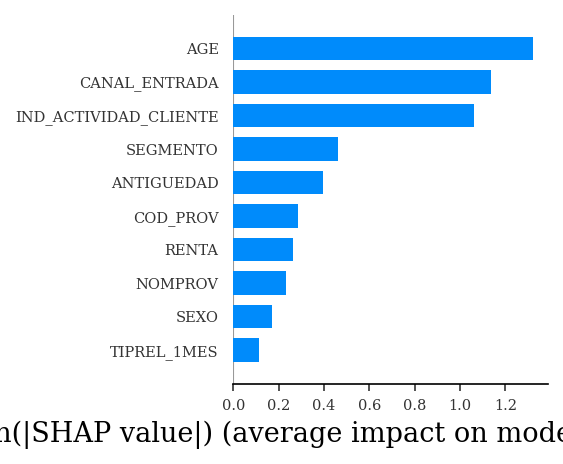

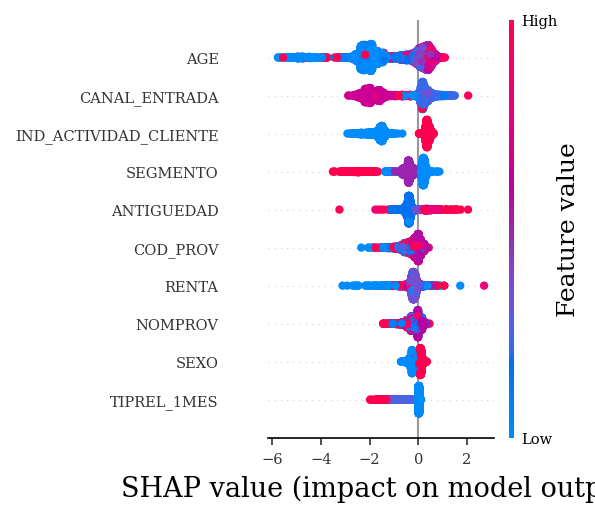


SANTANDER FIXED 60-DAY XGBOOST + ROS + SHAP COMPLETED

Performance table:
                  Metric      Test set 5-fold CV (mean ± SD)
                     AUC         0.863       0.8510 ± 0.0110
            KS statistic         0.609       0.6136 ± 0.0146
                  Recall         0.682       0.6007 ± 0.0437
               Precision         0.024       0.0225 ± 0.0014
                F1-score         0.046       0.0433 ± 0.0027
                Accuracy         0.817       0.8284 ± 0.0026
             Brier score         0.103       0.0965 ± 0.0015
 Precision@10% / Lift@D1 0.031 / 4.798                     —
             Capture@10%         0.480                     —
Precision@20% / Lift@20% 0.024 / 3.687                     —
             Capture@20%         0.737                     —
Precision@30% / Lift@30% 0.019 / 2.946                     —
             Capture@30%         0.884                     —

Top five SHAP features:
 RANK               FEATURE  MEAN_ABS_SHAP  ME

In [ ]:
# ============================================================
# SANTANDER FIXED CUTOFF 60-DAY
# XGBOOST + RANDOM OVERSAMPLING + SHAP
#
# Outputs:
#   1. Five-fold cross-validation metrics
#   2. Holdout test metrics
#   3. Ranking metrics at Top 10%, 20%, 30%
#   4. Publication-style performance table
#   5. SHAP global importance and Top-5
#   6. SHAP bar plot (IEEE single column)
#   7. SHAP beeswarm plot (IEEE single column)
#   8. CSV and formatted Excel outputs
#
# GOOGLE COLAB — COPY AND RUN DIRECTLY
# ============================================================

# Bỏ dấu # ở dòng dưới nếu Colab chưa có thư viện:
# !pip install -q shap xgboost imbalanced-learn openpyxl

import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

import os

if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")

MYDRIVE_ROOT = "/content/drive/MyDrive"

if not Path(MYDRIVE_ROOT).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

CUTOFF_DAYS = 60

# Code tự tìm file trong MyDrive để tránh lỗi sai đường dẫn.
INPUT_FILENAME_CANDIDATES = [
    "Santander_CreditCard_Fixed60D_Model.csv",
    "santander_creditcard_fixed60d_model.csv",
    "Santander_Fixed60D_Model.csv"
]

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Santander_External_Validation_Results",
    "Fixed60D_XGBoost_ROS_SHAP"
)

Path(OUTPUT_DIR).mkdir(
    parents=True,
    exist_ok=True
)

ID_COL_CANDIDATES = [
    "NCODPERS",
    "CUSTOMER_ID",
    "CUSTOMER_NUMBER"
]

TARGET_COL_CANDIDATES = [
    "TARGET_60D",
    "TARGET"
]

TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

DECISION_THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000
MAX_SHAP_DISPLAY = 10

MODEL_NAME = "XGBoost + RandomOverSampling (ROS)"


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def find_input_file(root_dir, filenames):
    """
    Tìm file theo danh sách tên ưu tiên trong toàn bộ MyDrive.
    """
    for filename in filenames:
        matches = list(Path(root_dir).rglob(filename))
        if matches:
            return str(matches[0])

    raise FileNotFoundError(
        "Không tìm thấy file Santander Fixed60D Model.\n"
        "Các tên đã tìm:\n"
        + "\n".join(f"- {name}" for name in filenames)
    )


def ensure_output_dir():
    Path(OUTPUT_DIR).mkdir(
        parents=True,
        exist_ok=True
    )

    if not Path(OUTPUT_DIR).is_dir():
        raise RuntimeError(
            "Không thể tạo thư mục output:\n"
            f"{OUTPUT_DIR}"
        )


def standardize_customer_id(series):
    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    return result.mask(
        result.str.upper().isin(invalid_values),
        pd.NA
    )


def get_xgb_model():
    """
    Một cấu hình duy nhất cho CV và mô hình cuối.
    """
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        max_bin=256,
        random_state=MODEL_RANDOM_STATE,
        n_jobs=2
    )


def fit_preprocess(
    X_train_raw,
    X_valid_raw,
    categorical_columns
):
    """
    Fit preprocessing chỉ trên training subset.

    - Ordinal encoding cho biến phân loại.
    - Unknown category = -1.
    - Median imputation cho toàn bộ feature sau encoding.
    """
    X_train_work = X_train_raw.copy()
    X_valid_work = X_valid_raw.copy()

    encoder = None

    if categorical_columns:
        for column in categorical_columns:
            X_train_work[column] = (
                X_train_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

            X_valid_work[column] = (
                X_valid_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
            dtype=np.float32
        )

        X_train_work[categorical_columns] = (
            encoder.fit_transform(
                X_train_work[categorical_columns]
            )
        )

        X_valid_work[categorical_columns] = (
            encoder.transform(
                X_valid_work[categorical_columns]
            )
        )

    for column in X_train_work.columns:
        X_train_work[column] = pd.to_numeric(
            X_train_work[column],
            errors="coerce"
        )

        X_valid_work[column] = pd.to_numeric(
            X_valid_work[column],
            errors="coerce"
        )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_processed = (
        imputer
        .fit_transform(X_train_work)
        .astype(np.float32)
    )

    X_valid_processed = (
        imputer
        .transform(X_valid_work)
        .astype(np.float32)
    )

    return (
        X_train_processed,
        X_valid_processed,
        imputer,
        encoder
    )


def calculate_ks(
    y_true,
    y_probability
):
    fpr, tpr, _ = roc_curve(
        y_true,
        y_probability
    )

    return float(
        np.max(tpr - fpr)
    )


def calculate_ranking_metrics(
    y_true,
    y_probability,
    top_rates=(0.10, 0.20, 0.30)
):
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n_customers = len(ranking)
    base_rate = float(ranking["Y_TRUE"].mean())
    total_positives = int(ranking["Y_TRUE"].sum())

    rows = []

    for rate in top_rates:
        top_n = max(
            1,
            int(np.ceil(n_customers * rate))
        )

        top_group = ranking.iloc[:top_n]

        precision_at_k = float(
            top_group["Y_TRUE"].mean()
        )

        captured_positives = int(
            top_group["Y_TRUE"].sum()
        )

        lift_at_k = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        capture_rate = (
            captured_positives / total_positives
            if total_positives > 0
            else np.nan
        )

        rows.append({
            "TOP_K": f"Top {int(rate * 100)}%",
            "TOP_RATE": float(rate),
            "CUSTOMERS": int(top_n),
            "PRECISION": precision_at_k,
            "LIFT": lift_at_k,
            "CAPTURED_POSITIVES": captured_positives,
            "CAPTURE_RATE": capture_rate
        })

    return pd.DataFrame(rows)


def create_decile_table(
    y_true,
    y_probability
):
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking["DECILE"] = pd.qcut(
        np.arange(len(ranking)),
        q=10,
        labels=[
            f"D{i}"
            for i in range(1, 11)
        ]
    )

    result = (
        ranking
        .groupby(
            "DECILE",
            observed=False
        )
        .agg(
            CUSTOMERS=("Y_TRUE", "count"),
            POSITIVES=("Y_TRUE", "sum"),
            ADOPTION_RATE=("Y_TRUE", "mean"),
            AVG_PRED_PROB=("Y_PROB", "mean")
        )
        .reset_index()
    )

    base_rate = float(
        ranking["Y_TRUE"].mean()
    )

    result["LIFT"] = (
        result["ADOPTION_RATE"] / base_rate
        if base_rate > 0
        else np.nan
    )

    return result


def get_ranking_row(
    ranking_table,
    top_rate
):
    matched_rows = ranking_table.loc[
        np.isclose(
            ranking_table["TOP_RATE"],
            top_rate,
            atol=1e-8
        )
    ]

    if matched_rows.empty:
        raise ValueError(
            f"Không tìm thấy ranking metric cho "
            f"Top {int(top_rate * 100)}%."
        )

    return matched_rows.iloc[0]


def format_test_metric(
    value,
    decimals=3
):
    return f"{float(value):.{decimals}f}"


def format_cv_metric(
    values,
    decimals=4
):
    mean_value = float(values.mean())
    std_value = float(values.std(ddof=1))

    return (
        f"{mean_value:.{decimals}f} ± "
        f"{std_value:.{decimals}f}"
    )


# ============================================================
# 4. FIND AND LOAD DATA
# ============================================================

INPUT_FILE = find_input_file(
    MYDRIVE_ROOT,
    INPUT_FILENAME_CANDIDATES
)

print("=" * 85)
print("SANTANDER FIXED 60-DAY CONFIGURATION")
print("=" * 85)
print("\nInput file:")
print(INPUT_FILE)
print("\nOutput directory:")
print(OUTPUT_DIR)

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nCác cột trong dữ liệu:")
print(df.columns.tolist())


# ============================================================
# 5. IDENTIFY ID AND TARGET
# ============================================================

TARGET_COL = next(
    (
        col
        for col in TARGET_COL_CANDIDATES
        if col in df.columns
    ),
    None
)

if TARGET_COL is None:
    raise ValueError(
        "Không tìm thấy TARGET_60D hoặc TARGET.\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )

ID_COL = next(
    (
        col
        for col in ID_COL_CANDIDATES
        if col in df.columns
    ),
    None
)

# Model file có thể đã loại ID.
# Khi đó tạo một ID nội bộ chỉ để lưu prediction.
if ID_COL is None:
    ID_COL = "ROW_ID"
    df[ID_COL] = np.arange(
        1,
        len(df) + 1
    ).astype(str)

print("\nID column:", ID_COL)
print("Target column:", TARGET_COL)


# ============================================================
# 6. CLEAN DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

if not df[TARGET_COL].isin([0, 1]).all():
    invalid_values = sorted(
        df.loc[
            ~df[TARGET_COL].isin([0, 1]),
            TARGET_COL
        ]
        .dropna()
        .unique()
        .tolist()
    )

    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1.\n"
        f"Giá trị không hợp lệ: {invalid_values}"
    )

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(np.int8)
)

duplicate_count = int(
    df[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_count > 0:
    raise ValueError(
        f"Có {duplicate_count:,} khách hàng bị trùng ID."
    )

df = df.replace(
    [
        "",
        " ",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None",
        "none"
    ],
    np.nan
)

df = (
    df
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

print("\n" + "=" * 85)
print("DATASET")
print("=" * 85)

print("Shape:", df.shape)

print("\nTarget distribution:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{df[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 7. EXCLUDED COLUMNS
# ============================================================

EXCLUDE_COLS = [
    ID_COL,
    TARGET_COL,

    # Target/card leakage columns
    "IND_TJCR_FIN_ULT1",
    "COUNT_CREDITCARD",
    "TOTAL_CARD",
    "RAW_TARGET",
    "TARGET_MONTH",
    "FIRST_CARD_MONTH",
    "FIRST_CARD_DATE",
    "FIRST_CARD_DATE_AFTER_CUTOFF",

    # Audit/time columns
    "FECHA_DATO",
    "FECHA_ALTA",
    "CUTOFF_DATE",
    "LAST_SNAPSHOT_DATE",
    "LAST_FEATURE_SNAPSHOT",
    "FEATURE_CUTOFF_DATE",
    "OBSERVATION_END_DATE",

    # Window/audit diagnostics not used as predictors
    "OBSERVED_FEATURE_DAYS",
    "N_FEATURE_SNAPSHOTS",
    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET",

    # Eligibility indicators
    "HAS_60D_FOLLOWUP",
    "EARLY_CARD_60D"
]

feature_cols = [
    column
    for column in df.columns
    if column not in EXCLUDE_COLS
]

if not feature_cols:
    raise ValueError(
        "Không còn feature nào sau khi loại EXCLUDE_COLS."
    )

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()
customer_ids = df[ID_COL].copy()


# ============================================================
# 8. DETECT NUMERIC AND CATEGORICAL FEATURES
# ============================================================

for column in X.columns:
    is_text = (
        pd.api.types.is_object_dtype(X[column])
        or pd.api.types.is_string_dtype(X[column])
        or isinstance(
            X[column].dtype,
            pd.CategoricalDtype
        )
    )

    if is_text:
        converted = pd.to_numeric(
            X[column],
            errors="coerce"
        )

        original_non_null = int(
            X[column].notna().sum()
        )

        converted_non_null = int(
            converted.notna().sum()
        )

        numeric_ratio = (
            converted_non_null / original_non_null
            if original_non_null > 0
            else 0
        )

        if numeric_ratio >= 0.80:
            X[column] = converted
        else:
            X[column] = X[column].astype("string")

categorical_columns = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category"
        ]
    )
    .columns
    .tolist()
)

print(
    "\nNumber of features:",
    len(feature_cols)
)

print("\nFeature list:")
for index, feature in enumerate(
    feature_cols,
    start=1
):
    print(f"{index:02d}. {feature}")

print("\nCategorical columns:")
print(categorical_columns)


# ============================================================
# 9. TRAIN–TEST SPLIT
# ============================================================

all_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SPLIT_RANDOM_STATE
)

X_train = (
    X.iloc[train_indices]
    .reset_index(drop=True)
)

X_test = (
    X.iloc[test_indices]
    .reset_index(drop=True)
)

y_train = (
    y.iloc[train_indices]
    .reset_index(drop=True)
)

y_test = (
    y.iloc[test_indices]
    .reset_index(drop=True)
)

test_ids = (
    customer_ids.iloc[test_indices]
    .reset_index(drop=True)
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "\nTrain positive rate:",
    f"{y_train.mean() * 100:.4f}%"
)

print(
    "Test positive rate:",
    f"{y_test.mean() * 100:.4f}%"
)


# ============================================================
# 10. FIVE-FOLD CROSS-VALIDATION
# ============================================================

stratified_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=MODEL_RANDOM_STATE
)

cv_rows = []

for fold, (
    fold_train_indices,
    fold_valid_indices
) in enumerate(
    stratified_cv.split(
        X_train,
        y_train
    ),
    start=1
):
    print(
        f"\nRunning fold {fold}/{N_SPLITS}..."
    )

    X_fold_train = (
        X_train.iloc[fold_train_indices]
        .copy()
    )

    X_fold_valid = (
        X_train.iloc[fold_valid_indices]
        .copy()
    )

    y_fold_train = (
        y_train.iloc[fold_train_indices]
        .copy()
    )

    y_fold_valid = (
        y_train.iloc[fold_valid_indices]
        .copy()
    )

    (
        X_fold_train_processed,
        X_fold_valid_processed,
        _,
        _
    ) = fit_preprocess(
        X_fold_train,
        X_fold_valid,
        categorical_columns
    )

    ros = RandomOverSampler(
        random_state=MODEL_RANDOM_STATE
    )

    X_fold_ros, y_fold_ros = ros.fit_resample(
        X_fold_train_processed,
        y_fold_train.to_numpy()
    )

    fold_model = get_xgb_model()

    fold_model.fit(
        X_fold_ros,
        y_fold_ros
    )

    y_valid_probability = (
        fold_model
        .predict_proba(
            X_fold_valid_processed
        )[:, 1]
    )

    y_valid_prediction = (
        y_valid_probability
        >= DECISION_THRESHOLD
    ).astype(np.int8)

    fold_result = {
        "FOLD": fold,
        "AUC": roc_auc_score(
            y_fold_valid,
            y_valid_probability
        ),
        "KS": calculate_ks(
            y_fold_valid,
            y_valid_probability
        ),
        "RECALL": recall_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "PRECISION": precision_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_fold_valid,
            y_valid_prediction
        ),
        "BRIER": brier_score_loss(
            y_fold_valid,
            y_valid_probability
        )
    }

    cv_rows.append(fold_result)

    print(
        f"AUC={fold_result['AUC']:.4f} | "
        f"KS={fold_result['KS']:.4f} | "
        f"Recall={fold_result['RECALL']:.4f} | "
        f"Precision={fold_result['PRECISION']:.4f} | "
        f"F1={fold_result['F1']:.4f}"
    )

    del fold_model
    del ros
    del X_fold_train_processed
    del X_fold_valid_processed
    del X_fold_ros
    del y_fold_ros

    gc.collect()

cv_results = pd.DataFrame(cv_rows)

cv_metric_columns = [
    "AUC",
    "KS",
    "RECALL",
    "PRECISION",
    "F1",
    "ACCURACY",
    "BRIER"
]

cv_summary = pd.DataFrame([
    {
        "METRIC": metric,
        "MEAN": float(
            cv_results[metric].mean()
        ),
        "STD": float(
            cv_results[metric].std(ddof=1)
        ),
        "MEAN_PLUS_MINUS_SD": (
            f"{cv_results[metric].mean():.4f} ± "
            f"{cv_results[metric].std(ddof=1):.4f}"
        )
    }
    for metric in cv_metric_columns
])

print("\n" + "=" * 85)
print("CROSS-VALIDATION SUMMARY")
print("=" * 85)

print(
    cv_summary[
        [
            "METRIC",
            "MEAN_PLUS_MINUS_SD"
        ]
    ].to_string(index=False)
)


# ============================================================
# 11. PREPROCESS FULL TRAIN AND TEST
# ============================================================

(
    X_train_processed,
    X_test_processed,
    final_imputer,
    final_encoder
) = fit_preprocess(
    X_train,
    X_test,
    categorical_columns
)


# ============================================================
# 12. RANDOM OVERSAMPLING
# ============================================================

final_ros = RandomOverSampler(
    random_state=MODEL_RANDOM_STATE
)

X_train_ros, y_train_ros = final_ros.fit_resample(
    X_train_processed,
    y_train.to_numpy()
)

print("\n" + "=" * 85)
print("RANDOM OVERSAMPLING")
print("=" * 85)

print("Before ROS:", X_train_processed.shape)
print("After ROS :", X_train_ros.shape)

print("\nClass distribution after ROS:")
print(
    pd.Series(y_train_ros)
    .value_counts()
    .sort_index()
)


# ============================================================
# 13. TRAIN FINAL MODEL
# ============================================================

print("\nTraining final model...")

final_model = get_xgb_model()

final_model.fit(
    X_train_ros,
    y_train_ros
)

print("Final model training completed.")

# Alias để các ô code cũ vẫn có thể dùng tên xgb.
xgb = final_model


# ============================================================
# 14. TEST PREDICTIONS AND METRICS
# ============================================================

y_test_probability = (
    final_model
    .predict_proba(
        X_test_processed
    )[:, 1]
)

y_test_prediction = (
    y_test_probability
    >= DECISION_THRESHOLD
).astype(np.int8)

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

test_ks = calculate_ks(
    y_test,
    y_test_probability
)

test_recall = recall_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_precision = precision_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    y_test_prediction
)

test_brier = brier_score_loss(
    y_test,
    y_test_probability
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_prediction,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 85)
print("TEST RESULTS")
print("=" * 85)

print(f"AUC       : {test_auc:.6f}")
print(f"KS        : {test_ks:.6f}")
print(f"Recall    : {test_recall:.6f}")
print(f"Precision : {test_precision:.6f}")
print(f"F1        : {test_f1:.6f}")
print(f"Accuracy  : {test_accuracy:.6f}")
print(f"Brier     : {test_brier:.6f}")

print("\nConfusion matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_prediction,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 15. RANKING METRICS
# ============================================================

ranking_results = calculate_ranking_metrics(
    y_test,
    y_test_probability
)

decile_table = create_decile_table(
    y_test,
    y_test_probability
)

print("\n" + "=" * 85)
print("RANKING METRICS")
print("=" * 85)

print(
    ranking_results.to_string(index=False)
)

predictions = pd.DataFrame({
    ID_COL: test_ids.to_numpy(),
    "Y_TRUE": y_test.to_numpy(),
    "Y_PROB": np.asarray(y_test_probability),
    "Y_PRED": np.asarray(y_test_prediction)
})

top10 = get_ranking_row(
    ranking_results,
    0.10
)

top20 = get_ranking_row(
    ranking_results,
    0.20
)

top30 = get_ranking_row(
    ranking_results,
    0.30
)


# ============================================================
# 16. PUBLICATION-STYLE PERFORMANCE TABLE
# ============================================================

performance_table = pd.DataFrame([
    {
        "Metric": "AUC",
        "Test set": format_test_metric(test_auc),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["AUC"]
        )
    },
    {
        "Metric": "KS statistic",
        "Test set": format_test_metric(test_ks),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["KS"]
        )
    },
    {
        "Metric": "Recall",
        "Test set": format_test_metric(test_recall),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["RECALL"]
        )
    },
    {
        "Metric": "Precision",
        "Test set": format_test_metric(test_precision),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["PRECISION"]
        )
    },
    {
        "Metric": "F1-score",
        "Test set": format_test_metric(test_f1),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["F1"]
        )
    },
    {
        "Metric": "Accuracy",
        "Test set": format_test_metric(test_accuracy),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["ACCURACY"]
        )
    },
    {
        "Metric": "Brier score",
        "Test set": format_test_metric(test_brier),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["BRIER"]
        )
    },
    {
        "Metric": "Precision@10% / Lift@D1",
        "Test set": (
            f"{float(top10['PRECISION']):.3f} / "
            f"{float(top10['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@10%",
        "Test set": format_test_metric(
            top10["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@20% / Lift@20%",
        "Test set": (
            f"{float(top20['PRECISION']):.3f} / "
            f"{float(top20['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@20%",
        "Test set": format_test_metric(
            top20["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@30% / Lift@30%",
        "Test set": (
            f"{float(top30['PRECISION']):.3f} / "
            f"{float(top30['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@30%",
        "Test set": format_test_metric(
            top30["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    }
])

print("\n" + "=" * 95)
print("PUBLICATION-STYLE PERFORMANCE TABLE")
print("=" * 95)

print(
    performance_table.to_string(index=False)
)


# ============================================================
# 17. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 18. PREPARE SHAP SAMPLE
# ============================================================

shap_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_processed)
)

random_generator = np.random.default_rng(
    MODEL_RANDOM_STATE
)

shap_indices = random_generator.choice(
    len(X_test_processed),
    size=shap_sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_test_processed[shap_indices],
    columns=feature_cols
).astype(np.float32)

print("\n" + "=" * 85)
print("SHAP ANALYSIS")
print("=" * 85)

print("SHAP sample size:", shap_sample_size)
print("SHAP input shape:", X_shap.shape)


# ============================================================
# 19. CALCULATE SHAP VALUES
# ============================================================

print("\nComputing SHAP values...")

shap_explainer = shap.TreeExplainer(
    final_model
)

try:
    shap_output = shap_explainer(
        X_shap
    )

    shap_values = np.asarray(
        shap_output.values
    )

except Exception:
    shap_values_raw = (
        shap_explainer
        .shap_values(
            X_shap
        )
    )

    if isinstance(shap_values_raw, list):
        shap_values = np.asarray(
            shap_values_raw[-1]
        )
    else:
        shap_values = np.asarray(
            shap_values_raw
        )

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        "SHAP shape không khớp dữ liệu:\n"
        f"SHAP shape: {shap_values.shape}\n"
        f"X_SHAP shape: {X_shap.shape}"
    )

if not np.isfinite(shap_values).all():
    raise ValueError(
        "SHAP values có NaN hoặc infinity."
    )

print("SHAP values shape:", shap_values.shape)


# ============================================================
# 20. SHAP GLOBAL IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "FEATURE": feature_cols,
    "MEAN_ABS_SHAP": np.abs(
        shap_values
    ).mean(axis=0),
    "MEAN_SIGNED_SHAP": shap_values.mean(
        axis=0
    )
})

shap_importance = (
    shap_importance
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "RANK",
    np.arange(
        1,
        len(shap_importance) + 1
    )
)

top5_shap = (
    shap_importance
    .head(5)
    .copy()
)

print("\nTop 10 SHAP features:")
print(
    shap_importance
    .head(10)
    .to_string(index=False)
)

print("\nTop five SHAP features:")
print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)


# ============================================================
# 21. SHAP BAR PLOT — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_bar_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Santander_Fixed60D_SHAP_Bar_600dpi.png"
)

shap_bar_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Santander_Fixed60D_SHAP_Bar.pdf"
)

plt.close("all")

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=MAX_SHAP_DISPLAY,
    show=False,
    plot_size=None
)

fig = plt.gcf()
fig.set_size_inches(
    3.5,
    3.0
)

for ax in fig.axes:
    ax.tick_params(
        labelsize=7
    )

fig.subplots_adjust(
    left=0.36,
    right=0.96,
    top=0.98,
    bottom=0.16
)

fig.savefig(
    shap_bar_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    shap_bar_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

plt.show()
plt.close(fig)


# ============================================================
# 22. SHAP BEESWARM — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_beeswarm_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Santander_Fixed60D_SHAP_Beeswarm_600dpi.png"
)

shap_beeswarm_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Santander_Fixed60D_SHAP_Beeswarm.pdf"
)

plt.close("all")

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=MAX_SHAP_DISPLAY,
    show=False,
    plot_size=None
)

fig = plt.gcf()
fig.set_size_inches(
    3.5,
    3.4
)

for ax in fig.axes:
    ax.tick_params(
        labelsize=7
    )

fig.subplots_adjust(
    left=0.36,
    right=0.90,
    top=0.98,
    bottom=0.16
)

fig.savefig(
    shap_beeswarm_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    shap_beeswarm_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

plt.show()
plt.close(fig)


# ============================================================
# 23. FINAL MACHINE-READABLE RESULT TABLE
# ============================================================

final_results = pd.DataFrame([{
    "MODEL": MODEL_NAME,
    "CUTOFF_DAYS": CUTOFF_DAYS,

    "N_CUSTOMERS": len(df),
    "N_TRAIN": len(X_train),
    "N_TEST": len(X_test),
    "N_FEATURES": len(feature_cols),

    "BASE_RATE": float(y.mean()),

    "CV_AUC_MEAN": float(
        cv_results["AUC"].mean()
    ),
    "CV_AUC_STD": float(
        cv_results["AUC"].std(ddof=1)
    ),

    "CV_KS_MEAN": float(
        cv_results["KS"].mean()
    ),
    "CV_KS_STD": float(
        cv_results["KS"].std(ddof=1)
    ),

    "CV_RECALL_MEAN": float(
        cv_results["RECALL"].mean()
    ),
    "CV_RECALL_STD": float(
        cv_results["RECALL"].std(ddof=1)
    ),

    "CV_PRECISION_MEAN": float(
        cv_results["PRECISION"].mean()
    ),
    "CV_PRECISION_STD": float(
        cv_results["PRECISION"].std(ddof=1)
    ),

    "CV_F1_MEAN": float(
        cv_results["F1"].mean()
    ),
    "CV_F1_STD": float(
        cv_results["F1"].std(ddof=1)
    ),

    "CV_ACCURACY_MEAN": float(
        cv_results["ACCURACY"].mean()
    ),
    "CV_ACCURACY_STD": float(
        cv_results["ACCURACY"].std(ddof=1)
    ),

    "CV_BRIER_MEAN": float(
        cv_results["BRIER"].mean()
    ),
    "CV_BRIER_STD": float(
        cv_results["BRIER"].std(ddof=1)
    ),

    "TEST_AUC": float(test_auc),
    "TEST_KS": float(test_ks),
    "TEST_RECALL": float(test_recall),
    "TEST_PRECISION": float(test_precision),
    "TEST_F1": float(test_f1),
    "TEST_ACCURACY": float(test_accuracy),
    "TEST_BRIER": float(test_brier),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "PRECISION_AT_10": float(
        top10["PRECISION"]
    ),
    "LIFT_AT_10": float(
        top10["LIFT"]
    ),
    "CAPTURE_RATE_AT_10": float(
        top10["CAPTURE_RATE"]
    ),

    "PRECISION_AT_20": float(
        top20["PRECISION"]
    ),
    "LIFT_AT_20": float(
        top20["LIFT"]
    ),
    "CAPTURE_RATE_AT_20": float(
        top20["CAPTURE_RATE"]
    ),

    "PRECISION_AT_30": float(
        top30["PRECISION"]
    ),
    "LIFT_AT_30": float(
        top30["LIFT"]
    ),
    "CAPTURE_RATE_AT_30": float(
        top30["CAPTURE_RATE"]
    ),

    "TOP_SHAP_FEATURE": str(
        top5_shap.iloc[0]["FEATURE"]
    )
}])


# ============================================================
# 24. SAVE CSV OUTPUTS
# ============================================================

ensure_output_dir()

final_results_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_final_results.csv"
)

cv_results_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_cross_validation_results.csv"
)

cv_summary_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_cv_mean_sd.csv"
)

ranking_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_ranking_metrics.csv"
)

decile_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_decile_table.csv"
)

predictions_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_test_predictions.csv"
)

performance_table_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_publication_performance_table.csv"
)

shap_importance_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_shap_global_importance.csv"
)

top5_shap_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_shap_top5.csv"
)

final_results.to_csv(
    final_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_results.to_csv(
    cv_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_summary.to_csv(
    cv_summary_file,
    index=False,
    encoding="utf-8-sig"
)

ranking_results.to_csv(
    ranking_file,
    index=False,
    encoding="utf-8-sig"
)

decile_table.to_csv(
    decile_file,
    index=False,
    encoding="utf-8-sig"
)

predictions.to_csv(
    predictions_file,
    index=False,
    encoding="utf-8-sig"
)

performance_table.to_csv(
    performance_table_file,
    index=False,
    encoding="utf-8-sig"
)

shap_importance.to_csv(
    shap_importance_file,
    index=False,
    encoding="utf-8-sig"
)

top5_shap.to_csv(
    top5_shap_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 25. SAVE FORMATTED EXCEL
# ============================================================

excel_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_xgboost_ros_metrics_shap.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Final results",
        index=False
    )

    performance_table.to_excel(
        writer,
        sheet_name="Performance table",
        index=False
    )

    cv_results.to_excel(
        writer,
        sheet_name="Cross validation",
        index=False
    )

    cv_summary.to_excel(
        writer,
        sheet_name="CV mean SD",
        index=False
    )

    ranking_results.to_excel(
        writer,
        sheet_name="Ranking",
        index=False
    )

    decile_table.to_excel(
        writer,
        sheet_name="Deciles",
        index=False
    )

    predictions.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP importance",
        index=False
    )

    top5_shap.to_excel(
        writer,
        sheet_name="SHAP top 5",
        index=False
    )

    performance_sheet = writer.sheets[
        "Performance table"
    ]

    performance_sheet.freeze_panes = "A2"

    performance_sheet.column_dimensions["A"].width = 32
    performance_sheet.column_dimensions["B"].width = 20
    performance_sheet.column_dimensions["C"].width = 28

    for cell in performance_sheet[1]:
        cell.font = cell.font.copy(
            bold=True
        )

        cell.alignment = cell.alignment.copy(
            horizontal="center",
            vertical="center"
        )

    for row in performance_sheet.iter_rows(
        min_row=2,
        max_row=performance_sheet.max_row,
        min_col=2,
        max_col=3
    ):
        for cell in row:
            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center"
            )


# ============================================================
# 26. FINAL REPORT
# ============================================================

print("\n" + "=" * 95)
print("SANTANDER FIXED 60-DAY XGBOOST + ROS + SHAP COMPLETED")
print("=" * 95)

print("\nPerformance table:")
print(
    performance_table.to_string(index=False)
)

print("\nTop five SHAP features:")
print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)

print("\nSaved Excel:")
print(excel_file)

print("\nSHAP bar figure:")
print(shap_bar_png)

print("\nSHAP beeswarm figure:")
print(shap_beeswarm_png)

print("\nSaved output directory:")
print(OUTPUT_DIR)

print("\nAll files currently saved in output directory:")

for saved_file in sorted(
    Path(OUTPUT_DIR).glob("*")
):
    print(saved_file.name)

In [ ]:
# ==========================================================
# TẠO LẠI XÁC SUẤT DỰ ĐOÁN CHO FAIRNESS
# SANTANDER FIXED 60-DAY
# ==========================================================

import numpy as np
import pandas as pd


# ----------------------------------------------------------
# 1. Kiểm tra dữ liệu test
# ----------------------------------------------------------

required_objects = [
    "X_test_processed",
    "y_test"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Không tìm thấy các biến cần thiết: "
        f"{missing_objects}.\n"
        "Hãy chạy lại các bước preprocessing, "
        "train-test split và huấn luyện mô hình."
    )


# Chuyển y_test về mảng một chiều để kiểm tra thống nhất
if isinstance(y_test, pd.Series):
    y_test_array = y_test.to_numpy()
else:
    y_test_array = np.asarray(y_test)

y_test_array = y_test_array.reshape(-1)


# ----------------------------------------------------------
# 2. Tự động tìm mô hình đã huấn luyện
# ----------------------------------------------------------

if "final_model" in globals():
    model_for_fairness = final_model
    model_name_for_fairness = "final_model"

elif "xgb" in globals():
    model_for_fairness = xgb
    model_name_for_fairness = "xgb"

else:
    raise NameError(
        "Không tìm thấy final_model hoặc xgb.\n"
        "Hãy chạy lại ô huấn luyện XGBoost."
    )

print(
    "Sử dụng mô hình:",
    model_name_for_fairness
)


# ----------------------------------------------------------
# 3. Kiểm tra mô hình có predict_proba hay không
# ----------------------------------------------------------

if not hasattr(
    model_for_fairness,
    "predict_proba"
):
    raise AttributeError(
        f"Mô hình {model_name_for_fairness} "
        "không hỗ trợ predict_proba()."
    )


# ----------------------------------------------------------
# 4. Tạo xác suất dự đoán
# ----------------------------------------------------------

predicted_probabilities = (
    model_for_fairness
    .predict_proba(
        X_test_processed
    )
)

if predicted_probabilities.ndim != 2:
    raise ValueError(
        "Kết quả predict_proba không phải ma trận hai chiều.\n"
        f"Shape nhận được: {predicted_probabilities.shape}"
    )

if predicted_probabilities.shape[1] < 2:
    raise ValueError(
        "predict_proba không trả về xác suất cho đủ hai lớp."
    )

# Xác suất thuộc lớp dương, tức TARGET_60D = 1
y_test_probability = (
    predicted_probabilities[:, 1]
    .astype(float)
)

# Alias để tương thích với các đoạn fairness code cũ
y_prob = y_test_probability.copy()


# ----------------------------------------------------------
# 5. Kiểm tra kích thước
# ----------------------------------------------------------

if len(y_test_probability) != len(y_test_array):
    raise ValueError(
        "Số xác suất dự đoán không bằng số nhãn test.\n"
        f"Số probability: {len(y_test_probability):,}\n"
        f"Số y_test: {len(y_test_array):,}"
    )


# ----------------------------------------------------------
# 6. Kiểm tra NaN và infinity
# ----------------------------------------------------------

if not np.isfinite(
    y_test_probability
).all():
    invalid_count = int(
        (
            ~np.isfinite(
                y_test_probability
            )
        ).sum()
    )

    raise ValueError(
        f"Xác suất dự đoán có {invalid_count:,} "
        "giá trị NaN hoặc infinity."
    )


# ----------------------------------------------------------
# 7. Kiểm tra miền xác suất
# ----------------------------------------------------------

outside_probability_range = (
    (y_test_probability < 0)
    | (y_test_probability > 1)
)

if outside_probability_range.any():
    invalid_count = int(
        outside_probability_range.sum()
    )

    raise ValueError(
        f"Có {invalid_count:,} xác suất nằm ngoài [0, 1]."
    )


# ----------------------------------------------------------
# 8. Tạo nhãn dự đoán tại threshold 0.5
# ----------------------------------------------------------

FAIRNESS_THRESHOLD = 0.50

y_test_prediction = (
    y_test_probability
    >= FAIRNESS_THRESHOLD
).astype(np.int8)

# Alias để tương thích với code cũ
y_pred = y_test_prediction.copy()


# ----------------------------------------------------------
# 9. Báo cáo kiểm tra
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("FAIRNESS PREDICTION CHECK — FIXED 60-DAY")
print("=" * 70)

print(
    "Số xác suất dự đoán:",
    f"{len(y_test_probability):,}"
)

print(
    "Số nhãn test:",
    f"{len(y_test_array):,}"
)

print(
    "Min probability:",
    f"{np.min(y_test_probability):.6f}"
)

print(
    "Max probability:",
    f"{np.max(y_test_probability):.6f}"
)

print(
    "Mean probability:",
    f"{np.mean(y_test_probability):.6f}"
)

print(
    "Median probability:",
    f"{np.median(y_test_probability):.6f}"
)

print(
    "Threshold:",
    FAIRNESS_THRESHOLD
)

print(
    "Predicted positive cases:",
    int(y_test_prediction.sum())
)

print(
    "Predicted positive rate:",
    f"{y_test_prediction.mean():.4%}"
)

print("\nĐã tạo thành công các biến:")
print("- y_test_probability")
print("- y_prob")
print("- y_test_prediction")
print("- y_pred")
print("- model_for_fairness")

Sử dụng mô hình: final_model

FAIRNESS PREDICTION CHECK — FIXED 60-DAY
Số xác suất dự đoán: 30,680
Số nhãn test: 30,680
Min probability: 0.000006
Max probability: 0.960435
Mean probability: 0.172181
Median probability: 0.003871
Threshold: 0.5
Predicted positive cases: 5687
Predicted positive rate: 18.5365%

Đã tạo thành công các biến:
- y_test_probability
- y_prob
- y_test_prediction
- y_pred
- model_for_fairness


Fairness

In [ ]:
# ==========================================================
# FAIRNESS METRICS BY SEX AND AGE — SANTANDER FIXED 60-DAY
#
# Required variables:
#   y_test              : true labels of holdout test set
#   y_test_probability  : predicted probabilities
#                        hoặc y_prob
#
# Protected attributes must come from the original test rows:
#   AGE
#   CLIENT_SEX
#
# Outputs:
#   n
#   Base rate
#   AUC
#   Brier
#   TPR@threshold
#   Selection rate@threshold
#   TPR@top-20%
# ==========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score
)


# ==========================================================
# 1. CONFIGURATION
# ==========================================================

DECISION_THRESHOLD = 0.50
TOP_RATE = 0.20

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "Santander_External_Validation_Results/"
    "Fixed60D_XGBoost_ROS_SHAP"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ==========================================================
# 2. IDENTIFY PREDICTED PROBABILITY VARIABLE
# ==========================================================

if "y_test_probability" in globals():
    probability = np.asarray(
        y_test_probability
    )

elif "y_prob" in globals():
    probability = np.asarray(
        y_prob
    )

else:
    raise NameError(
        "Không tìm thấy y_test_probability hoặc y_prob. "
        "Hãy chạy bước dự đoán mô hình trước."
    )


if "y_test" not in globals():
    raise NameError(
        "Không tìm thấy y_test."
    )

y_true = np.asarray(
    y_test
).reshape(-1).astype(int)

probability = np.asarray(
    probability
).reshape(-1).astype(float)

if not np.isfinite(probability).all():
    raise ValueError(
        "Predicted probabilities chứa NaN hoặc infinity."
    )

if ((probability < 0) | (probability > 1)).any():
    raise ValueError(
        "Predicted probabilities phải nằm trong đoạn [0, 1]."
    )

if not np.isin(y_true, [0, 1]).all():
    raise ValueError(
        "y_test phải chỉ chứa nhãn 0 và 1."
    )


# ==========================================================
# 3. GET ORIGINAL TEST DATA WITH AGE AND SEX
# ==========================================================

# Trường hợp pipeline dùng X_test là dữ liệu gốc trước encoding
if "X_test" in globals():

    protected_test = (
        X_test
        .copy()
        .reset_index(drop=True)
    )

# Trường hợp có test_indices và df gốc
elif (
    "test_indices" in globals()
    and "df" in globals()
):

    protected_test = (
        df.iloc[test_indices]
        .copy()
        .reset_index(drop=True)
    )

# Trường hợp dùng X_test_raw
elif "X_test_raw" in globals():

    protected_test = (
        X_test_raw
        .copy()
        .reset_index(drop=True)
    )

else:
    raise NameError(
        "Không tìm thấy dữ liệu test gốc chứa AGE và CLIENT_SEX.\n"
        "Cần có một trong các biến: X_test, X_test_raw, "
        "hoặc df cùng test_indices."
    )


# Chuẩn hóa tên cột về chữ hoa
protected_test.columns = (
    protected_test.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ==========================================================
# 4. AUTOMATICALLY IDENTIFY AGE AND SEX COLUMNS
# ==========================================================

age_candidates = [
    "AGE",
    "CUSTOMER_AGE"
]

sex_candidates = [
    "CLIENT_SEX",
    "SEX",
    "SEXO",
    "GENDER"
]

AGE_COL = next(
    (
        col
        for col in age_candidates
        if col in protected_test.columns
    ),
    None
)

SEX_COL = next(
    (
        col
        for col in sex_candidates
        if col in protected_test.columns
    ),
    None
)

if AGE_COL is None:
    raise ValueError(
        "Không tìm thấy cột AGE trong dữ liệu test.\n"
        f"Các cột hiện có:\n{protected_test.columns.tolist()}"
    )

if SEX_COL is None:
    raise ValueError(
        "Không tìm thấy cột CLIENT_SEX/SEX/SEXO "
        "trong dữ liệu test.\n"
        f"Các cột hiện có:\n{protected_test.columns.tolist()}"
    )

print("Age column:", AGE_COL)
print("Sex column:", SEX_COL)


# ==========================================================
# 5. ALIGN TEST DATA, LABELS AND PROBABILITIES
# ==========================================================

if not (
    len(protected_test)
    == len(y_true)
    == len(probability)
):
    raise ValueError(
        "Kích thước dữ liệu không khớp:\n"
        f"protected_test: {len(protected_test)}\n"
        f"y_test: {len(y_true)}\n"
        f"probability: {len(probability)}"
    )

fairness_data = pd.DataFrame({
    "Y_TRUE": y_true,
    "Y_PROB": probability,
    "AGE": pd.to_numeric(
        protected_test[AGE_COL],
        errors="coerce"
    ),
    "SEX_RAW": (
        protected_test[SEX_COL]
        .astype("string")
        .str.strip()
        .str.upper()
    )
})

fairness_data["Y_PRED"] = (
    fairness_data["Y_PROB"]
    >= DECISION_THRESHOLD
).astype(int)


# ==========================================================
# 6. STANDARDIZE SEX VALUES
# ==========================================================

def standardize_sex(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip().upper()

    male_values = {
        "M",
        "MALE",
        "NAM",
        "1",
        "H"
    }

    female_values = {
        "F",
        "FEMALE",
        "NỮ",
        "NU",
        "0",
        "V"
    }

    if value in male_values:
        return "Male"

    if value in female_values:
        return "Female"

    return pd.NA


fairness_data["SEX_GROUP"] = (
    fairness_data["SEX_RAW"]
    .apply(standardize_sex)
)


# ==========================================================
# 7. CREATE AGE GROUPS
# ==========================================================

fairness_data["AGE_GROUP"] = pd.cut(
    fairness_data["AGE"],
    bins=[
        -np.inf,
        29,
        45,
        np.inf
    ],
    labels=[
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ],
    right=True
)


print("\nProtected-attribute completeness:")
print(
    "Missing/unrecognized sex:",
    int(fairness_data["SEX_GROUP"].isna().sum())
)
print(
    "Missing age:",
    int(fairness_data["AGE"].isna().sum())
)
print(
    "Ungrouped age:",
    int(fairness_data["AGE_GROUP"].isna().sum())
)


# ==========================================================
# 8. FUNCTION TO CALCULATE GROUP METRICS
# ==========================================================

def calculate_group_metrics(
    group_df,
    group_name,
    top_rate=0.20,
    threshold=0.50
):
    """
    Tính các metric fairness cho một demographic group.

    TPR@top-20%:
        Số positive thực tế nằm trong top 20% xác suất
        chia cho tổng số positive thực tế của nhóm.
    """

    group_df = (
        group_df
        .dropna(
            subset=[
                "Y_TRUE",
                "Y_PROB"
            ]
        )
        .copy()
    )

    n = len(group_df)

    if n == 0:
        return {
            "Group": group_name,
            "n": 0,
            "Base rate": np.nan,
            "AUC": np.nan,
            "Brier": np.nan,
            "TPR@threshold": np.nan,
            "Selection rate@threshold": np.nan,
            "TPR@top-20%": np.nan
        }

    y_group = (
        group_df["Y_TRUE"]
        .to_numpy()
        .astype(int)
    )

    prob_group = (
        group_df["Y_PROB"]
        .to_numpy()
    )

    pred_group = (
        prob_group >= threshold
    ).astype(int)

    base_rate = float(
        y_group.mean()
    )

    # AUC chỉ xác định khi nhóm có đủ cả hai lớp
    if len(np.unique(y_group)) == 2:
        auc = float(
            roc_auc_score(
                y_group,
                prob_group
            )
        )
    else:
        auc = np.nan

    brier = float(
        brier_score_loss(
            y_group,
            prob_group
        )
    )

    # TPR tại threshold = Recall của positive class
    tpr_threshold = float(
        recall_score(
            y_group,
            pred_group,
            zero_division=0
        )
    )

    # Tỷ lệ khách hàng được mô hình chọn tại threshold
    selection_rate = float(
        pred_group.mean()
    )

    # ------------------------------------------------------
    # TPR@Top-20% within group
    # ------------------------------------------------------

    ranked_group = (
        group_df
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    top_n = max(
        1,
        int(
            np.ceil(
                len(ranked_group)
                * top_rate
            )
        )
    )

    top_group = ranked_group.iloc[:top_n]

    total_positives = int(
        ranked_group["Y_TRUE"].sum()
    )

    captured_positives = int(
        top_group["Y_TRUE"].sum()
    )

    tpr_top_k = (
        captured_positives / total_positives
        if total_positives > 0
        else np.nan
    )

    return {
        "Group": group_name,
        "n": int(n),
        "Base rate": base_rate,
        "AUC": auc,
        "Brier": brier,
        "TPR@threshold": tpr_threshold,
        "Selection rate@threshold": selection_rate,
        "TPR@top-20%": tpr_top_k
    }


# ==========================================================
# 9. CALCULATE SEX-GROUP METRICS
# ==========================================================

results = []

for sex_group in [
    "Male",
    "Female"
]:

    subset = fairness_data.loc[
        fairness_data["SEX_GROUP"]
        == sex_group
    ]

    results.append(
        calculate_group_metrics(
            subset,
            sex_group,
            top_rate=TOP_RATE,
            threshold=DECISION_THRESHOLD
        )
    )


# ==========================================================
# 10. CALCULATE AGE-GROUP METRICS
# ==========================================================

for age_group in [
    "Age <30",
    "Age 30–45",
    "Age ≥46"
]:

    subset = fairness_data.loc[
        fairness_data["AGE_GROUP"]
        .astype("string")
        == age_group
    ]

    results.append(
        calculate_group_metrics(
            subset,
            age_group,
            top_rate=TOP_RATE,
            threshold=DECISION_THRESHOLD
        )
    )


# ==========================================================
# 11. CREATE FINAL TABLE
# ==========================================================

fairness_table = pd.DataFrame(
    results
)

group_order = [
    "Male",
    "Female",
    "Age <30",
    "Age 30–45",
    "Age ≥46"
]

fairness_table["Group"] = pd.Categorical(
    fairness_table["Group"],
    categories=group_order,
    ordered=True
)

fairness_table = (
    fairness_table
    .sort_values("Group")
    .reset_index(drop=True)
)

fairness_table["Group"] = (
    fairness_table["Group"]
    .astype(str)
)


# ==========================================================
# 12. DISPLAY TABLE
# ==========================================================

display_table = fairness_table.copy()

metric_columns = [
    "Base rate",
    "AUC",
    "Brier",
    "TPR@threshold",
    "Selection rate@threshold",
    "TPR@top-20%"
]

display_table[metric_columns] = (
    display_table[metric_columns]
    .round(3)
)

print("\n" + "=" * 110)
print("FAIRNESS METRICS BY SEX AND AGE — FIXED 60-DAY")
print("=" * 110)

print(
    display_table.to_string(
        index=False
    )
)


# ==========================================================
# 13. FAIRNESS SUMMARY INDICATORS
# ==========================================================

male_row = fairness_table.loc[
    fairness_table["Group"] == "Male"
].iloc[0]

female_row = fairness_table.loc[
    fairness_table["Group"] == "Female"
].iloc[0]

sex_selection_min = min(
    male_row["Selection rate@threshold"],
    female_row["Selection rate@threshold"]
)

sex_selection_max = max(
    male_row["Selection rate@threshold"],
    female_row["Selection rate@threshold"]
)

sex_disparate_impact = (
    sex_selection_min / sex_selection_max
    if pd.notna(sex_selection_max)
    and sex_selection_max > 0
    else np.nan
)

sex_tpr_gap = abs(
    male_row["TPR@threshold"]
    - female_row["TPR@threshold"]
)

sex_auc_gap = abs(
    male_row["AUC"]
    - female_row["AUC"]
)


age_rows = fairness_table.loc[
    fairness_table["Group"].isin([
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ])
]

age_selection_rates = (
    age_rows[
        "Selection rate@threshold"
    ]
)

age_selection_min = age_selection_rates.min()
age_selection_max = age_selection_rates.max()

age_disparate_impact = (
    age_selection_min / age_selection_max
    if pd.notna(age_selection_max)
    and age_selection_max > 0
    else np.nan
)

age_tpr_gap = (
    age_rows["TPR@threshold"].max()
    - age_rows["TPR@threshold"].min()
)

age_auc_gap = (
    age_rows["AUC"].max()
    - age_rows["AUC"].min()
)

fairness_summary = pd.DataFrame({
    "Audit dimension": [
        "Sex",
        "Age"
    ],
    "Disparate impact": [
        sex_disparate_impact,
        age_disparate_impact
    ],
    "TPR gap": [
        sex_tpr_gap,
        age_tpr_gap
    ],
    "AUC gap": [
        sex_auc_gap,
        age_auc_gap
    ]
})

print("\n" + "=" * 80)
print("FAIRNESS SUMMARY")
print("=" * 80)

print(
    fairness_summary
    .round(3)
    .to_string(index=False)
)


# ==========================================================
# 14. SAVE RESULTS
# ==========================================================

fairness_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_fairness_metrics_by_sex_age.csv"
)

fairness_summary_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_fairness_summary_sex_age.csv"
)

fairness_table.to_csv(
    fairness_file,
    index=False,
    encoding="utf-8-sig"
)

fairness_summary.to_csv(
    fairness_summary_file,
    index=False,
    encoding="utf-8-sig"
)


fairness_excel_file = os.path.join(
    OUTPUT_DIR,
    "santander_fixed60d_fairness_metrics.xlsx"
)

with pd.ExcelWriter(
    fairness_excel_file,
    engine="openpyxl"
) as writer:
    fairness_table.to_excel(
        writer,
        sheet_name="Group metrics",
        index=False
    )
    fairness_summary.to_excel(
        writer,
        sheet_name="Fairness summary",
        index=False
    )

print("\nĐã lưu bảng fairness:")
print(fairness_file)

print("\nĐã lưu fairness summary:")
print(fairness_summary_file)

print("\nĐã lưu file Excel fairness:")
print(fairness_excel_file)

Age column: AGE
Sex column: SEXO

Protected-attribute completeness:
Missing/unrecognized sex: 1
Missing age: 0
Ungrouped age: 0

FAIRNESS METRICS BY SEX AND AGE — FIXED 60-DAY
    Group     n  Base rate   AUC  Brier  TPR@threshold  Selection rate@threshold  TPR@top-20%
     Male 15255      0.005 0.882  0.079          0.667                     0.145        0.783
   Female 15424      0.008 0.842  0.125          0.690                     0.225        0.636
  Age <30 18446      0.001 0.933  0.020          0.440                     0.034        0.920
Age 30–45  8008      0.013 0.717  0.242          0.757                     0.445        0.430
  Age ≥46  4226      0.016 0.747  0.200          0.652                     0.355        0.545

FAIRNESS SUMMARY
Audit dimension  Disparate impact  TPR gap  AUC gap
            Sex             0.644    0.023    0.040
            Age             0.076    0.317    0.216

Đã lưu bảng fairness:
/content/drive/MyDrive/Santander_External_Validation_Results/Fi